## 1 单栏预测头数波动时间序列

In [3]:
import pandas as pd

df = pd.read_excel('data/育肥4-2单元饲喂记录-2025-08-26--2025-12-16-单栏分析.xlsx', index_col=0)

food_df = pd.read_excel('data/std_food_table.xlsx', index_col=False)

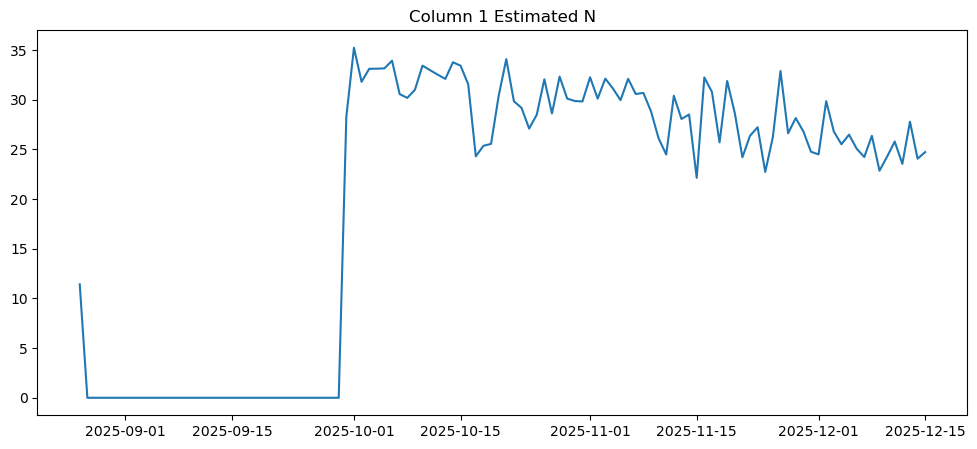

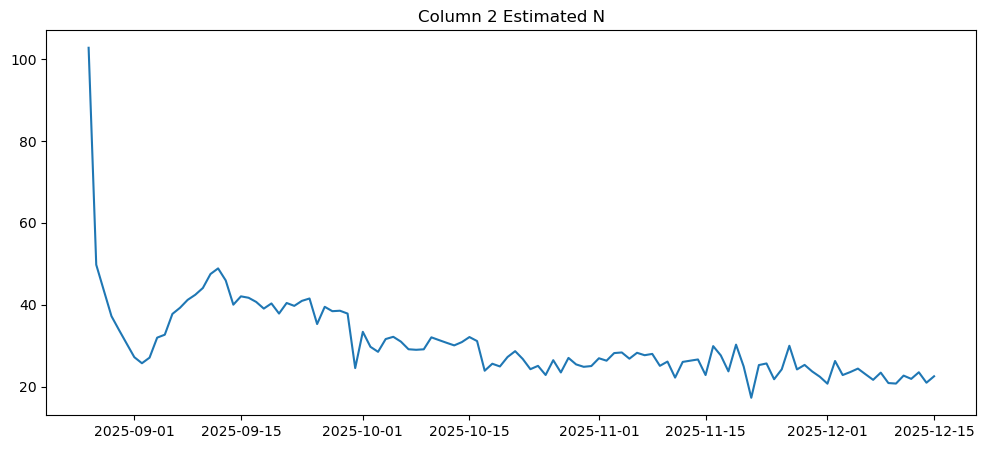

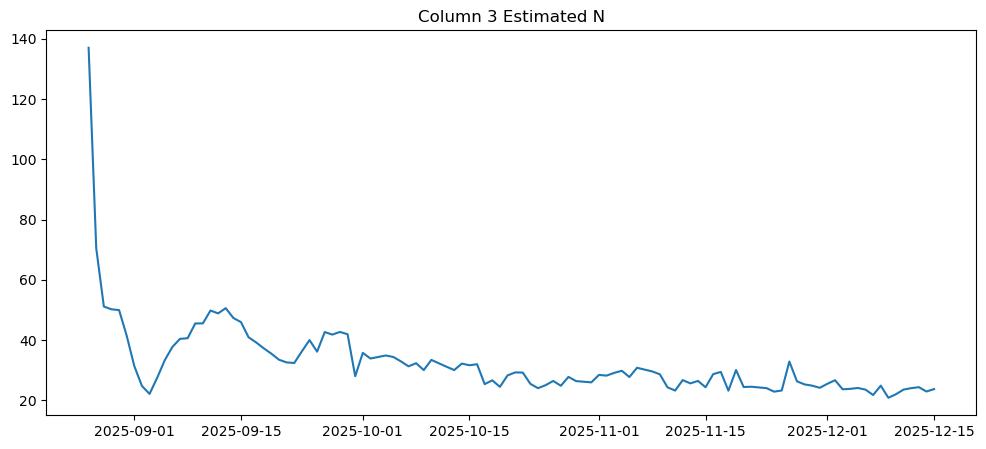

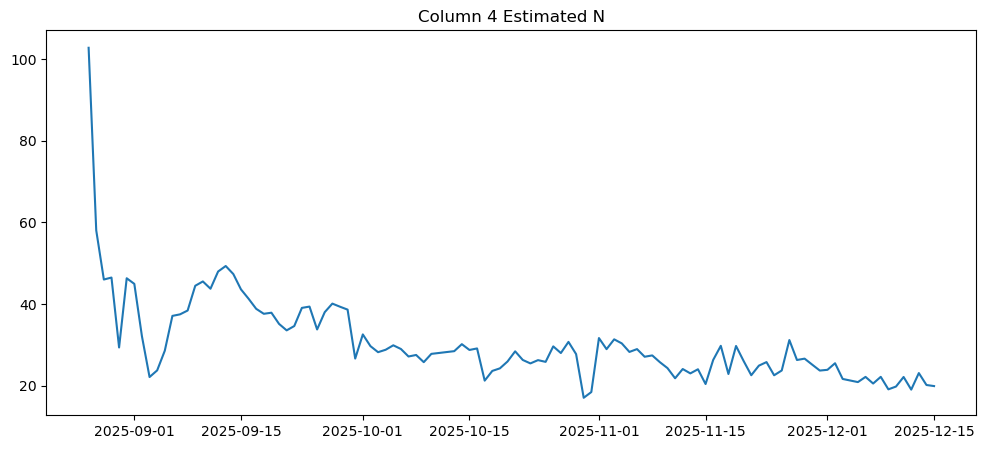

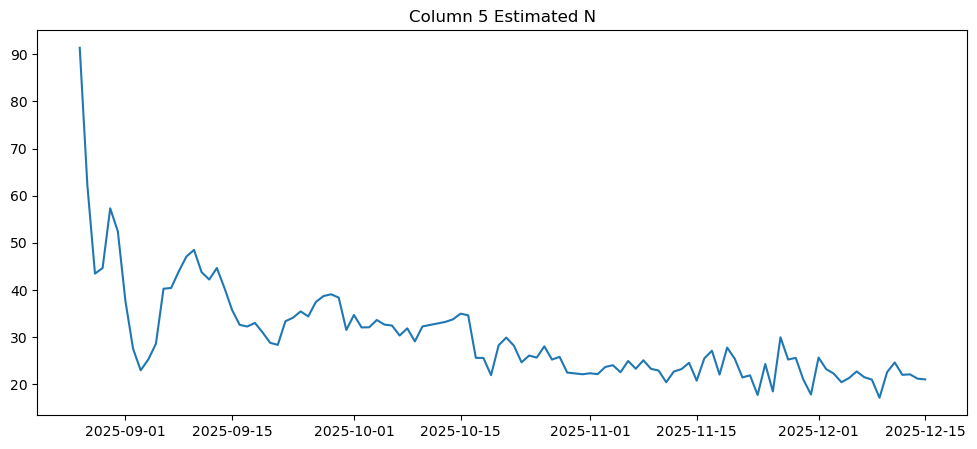

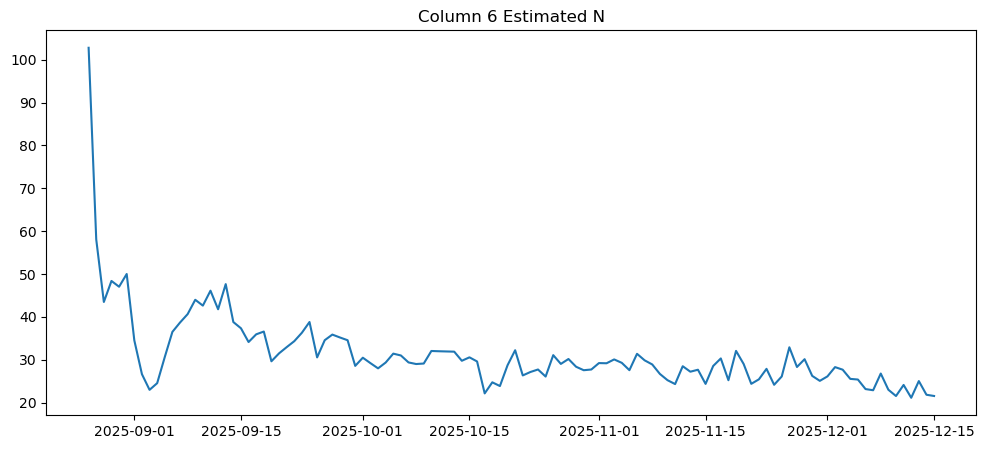

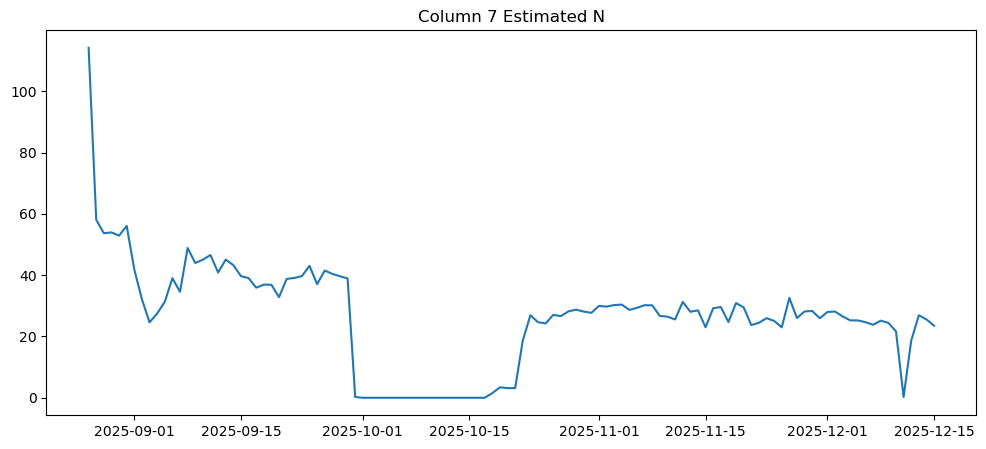

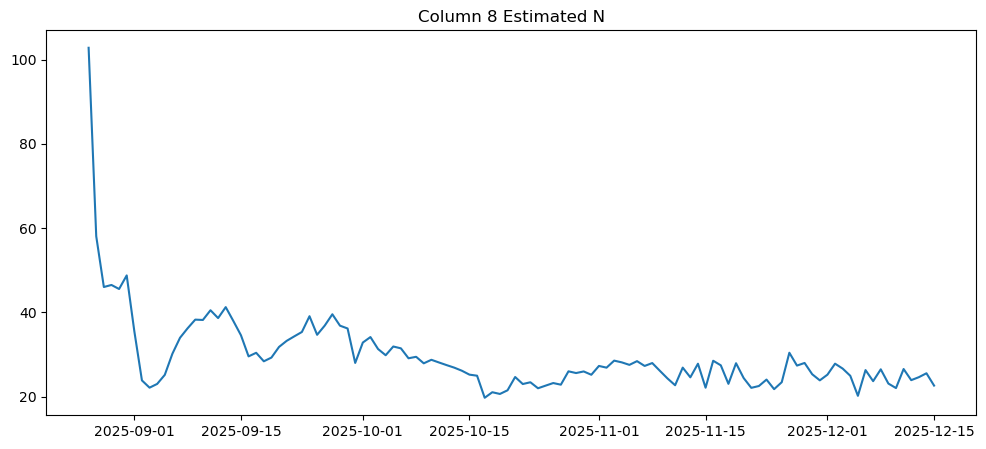

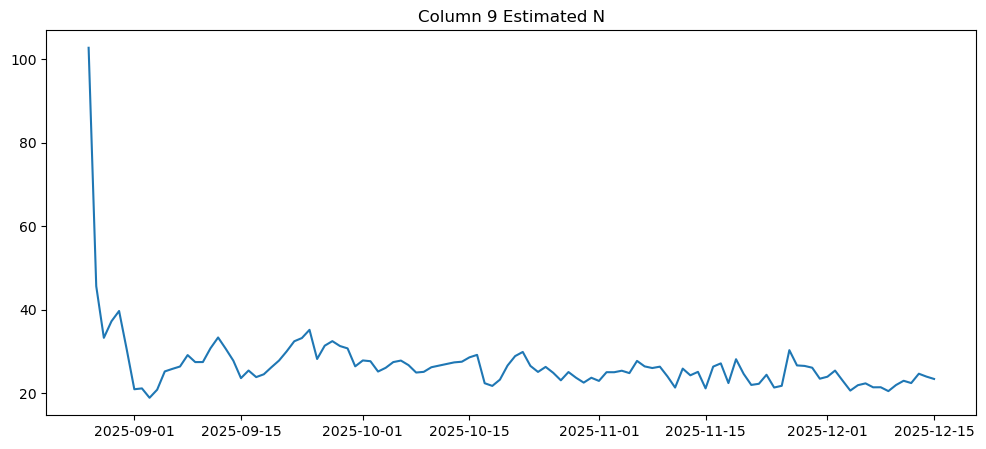

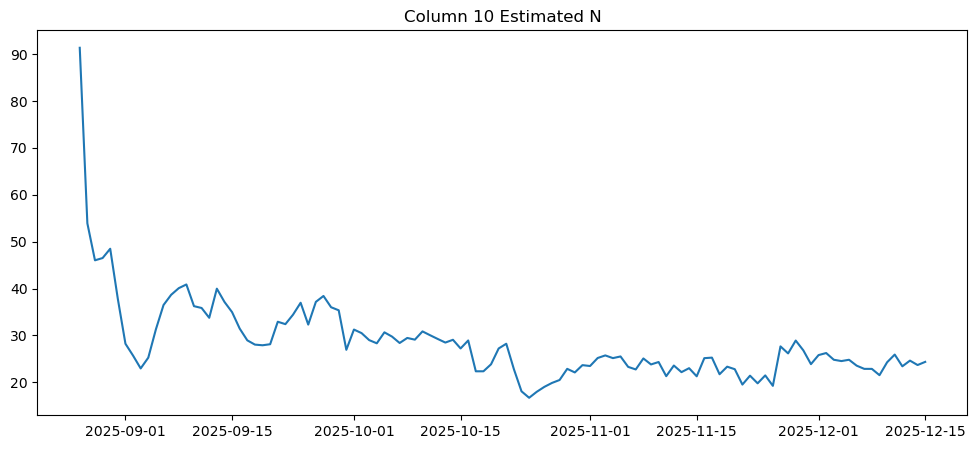

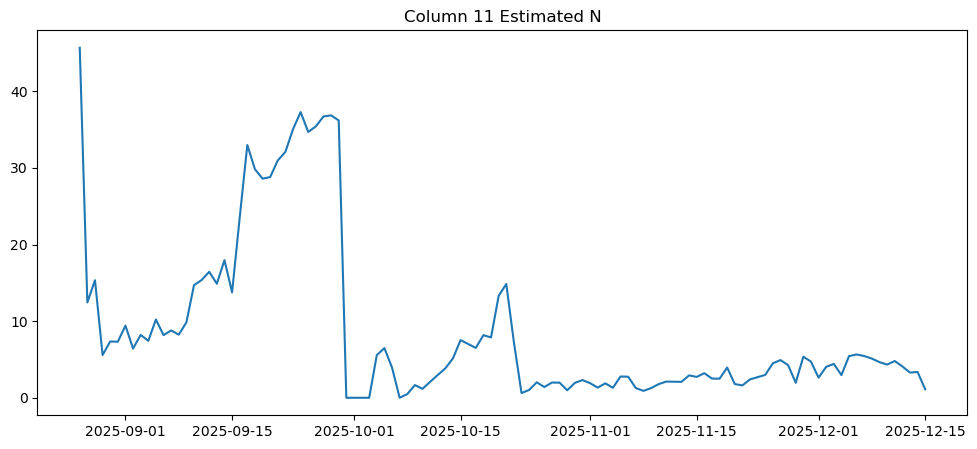

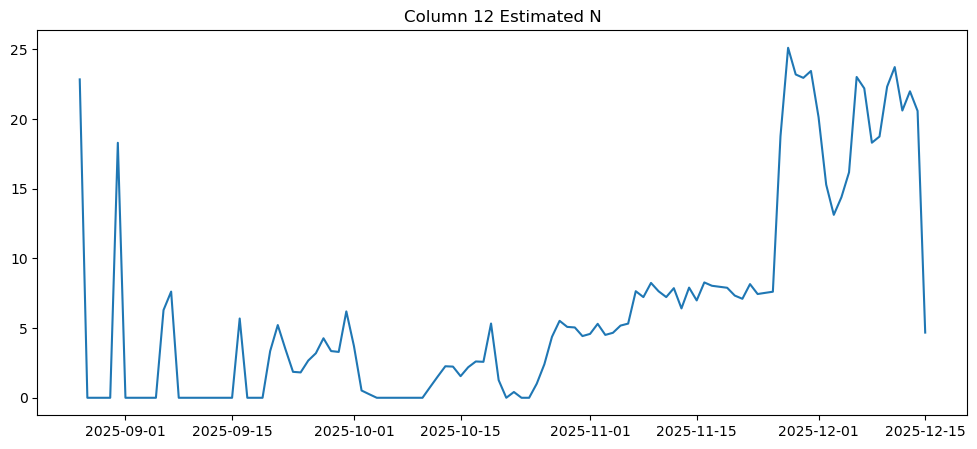

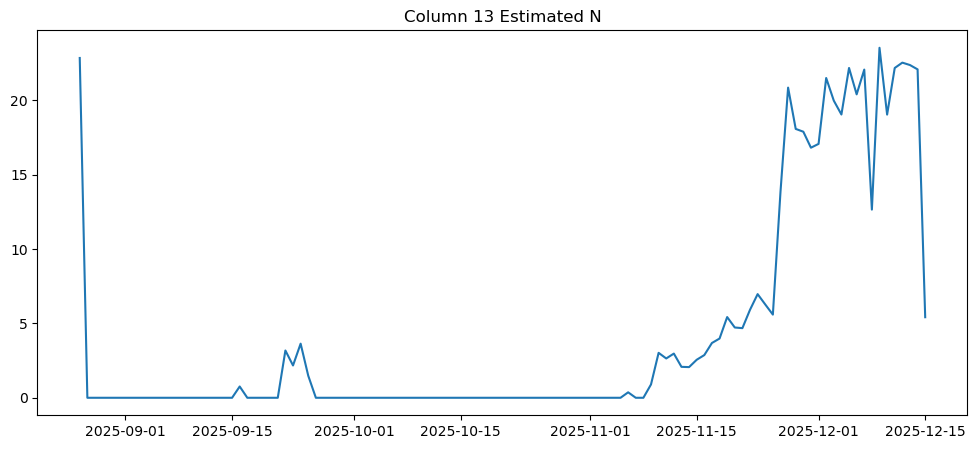

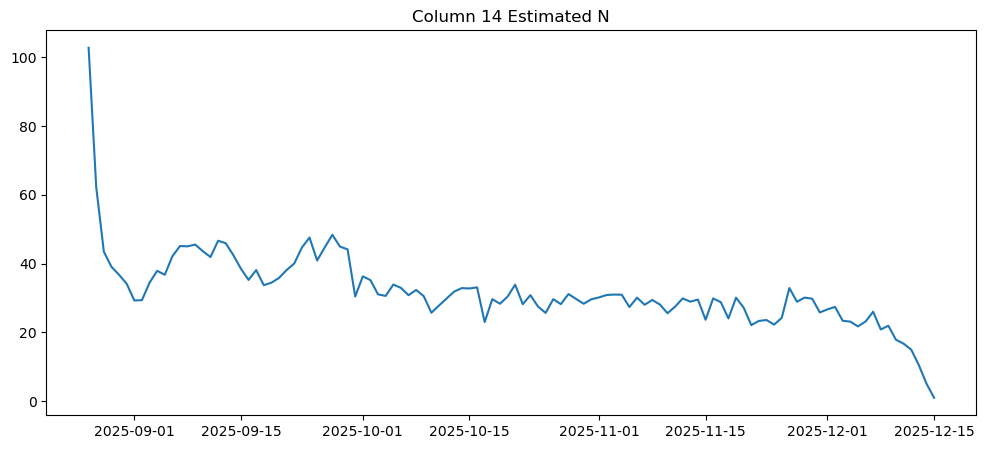

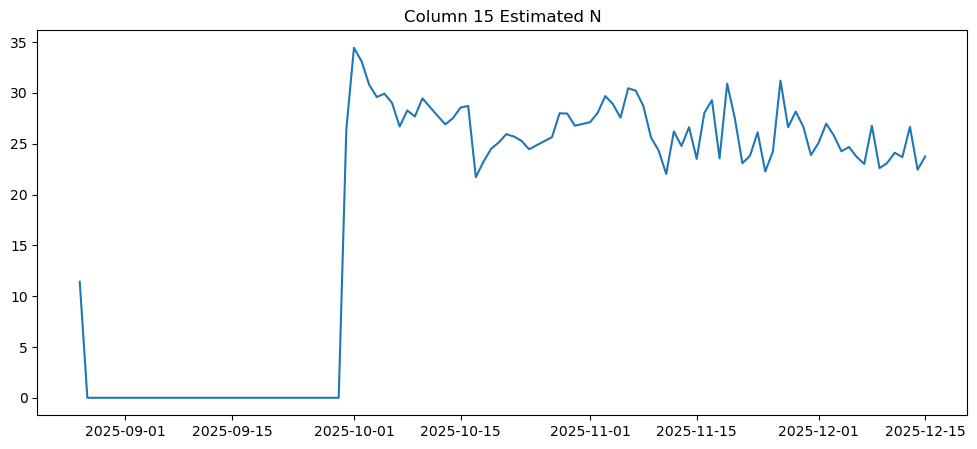

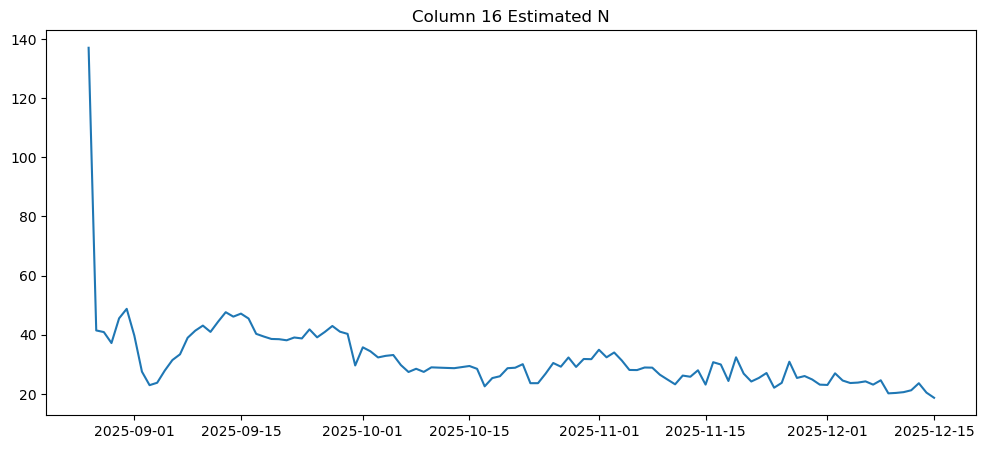

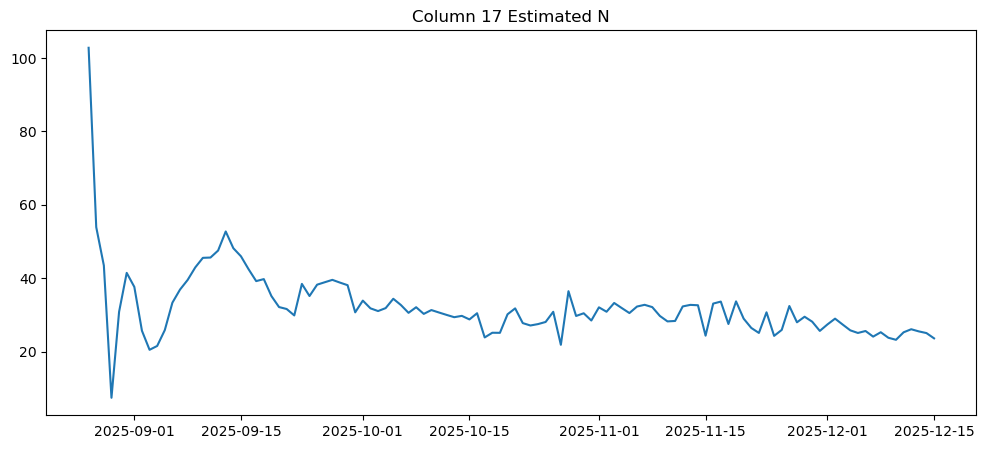

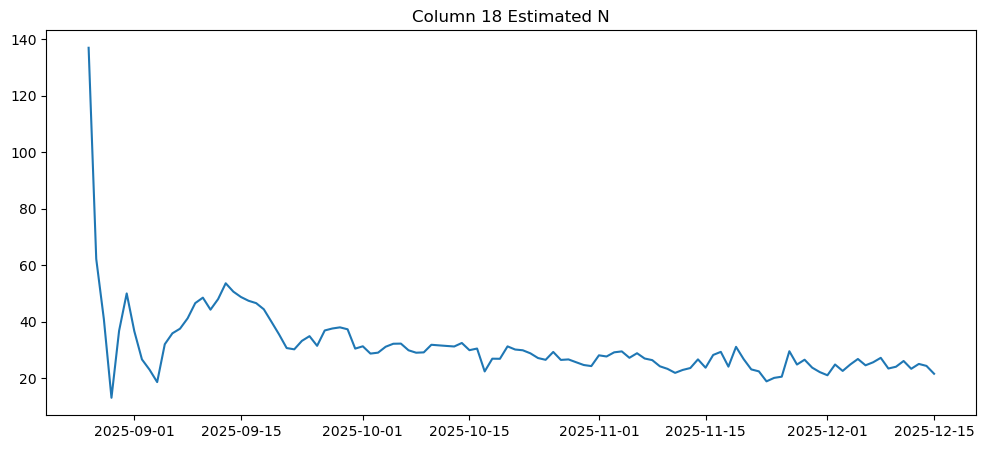

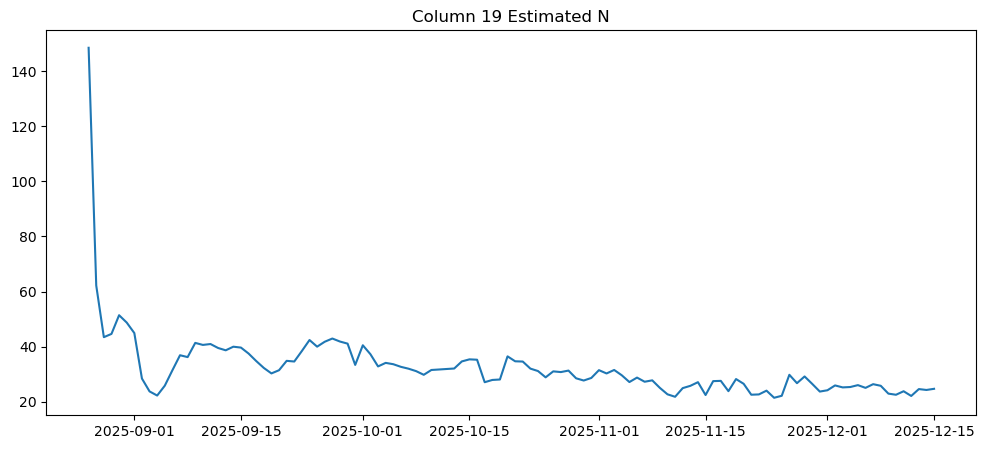

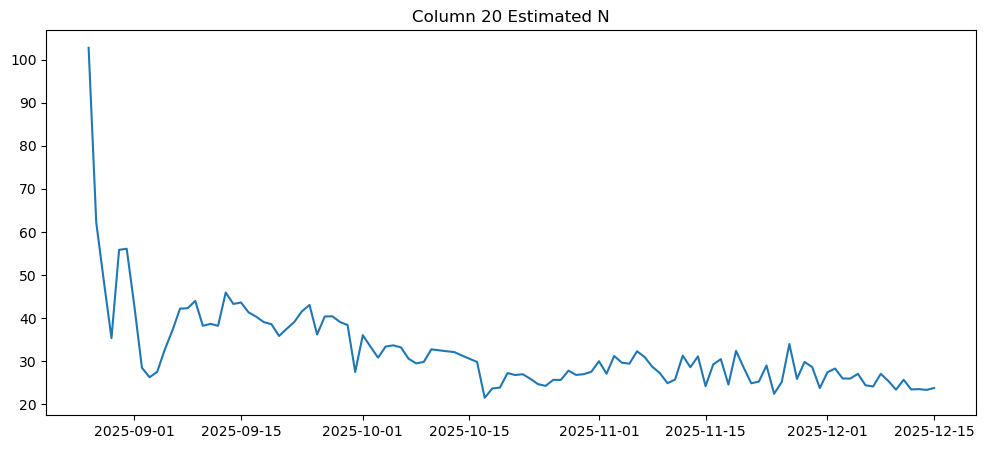

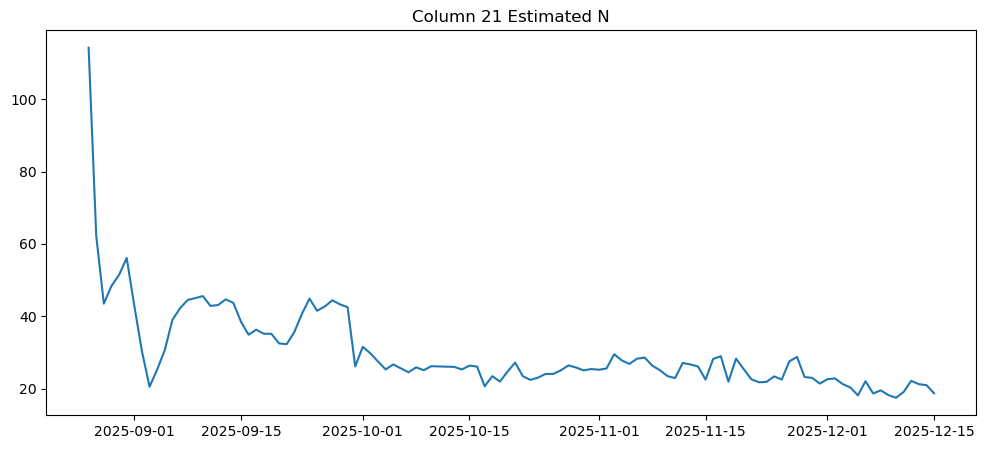

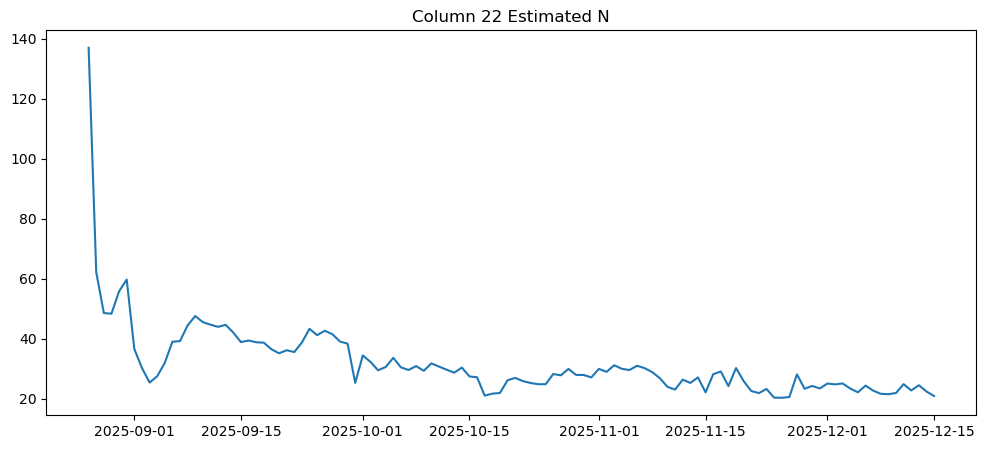

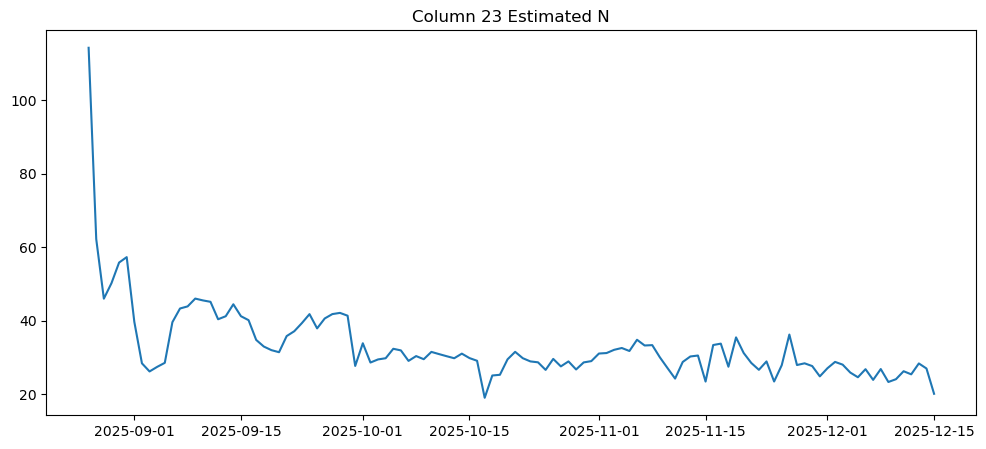

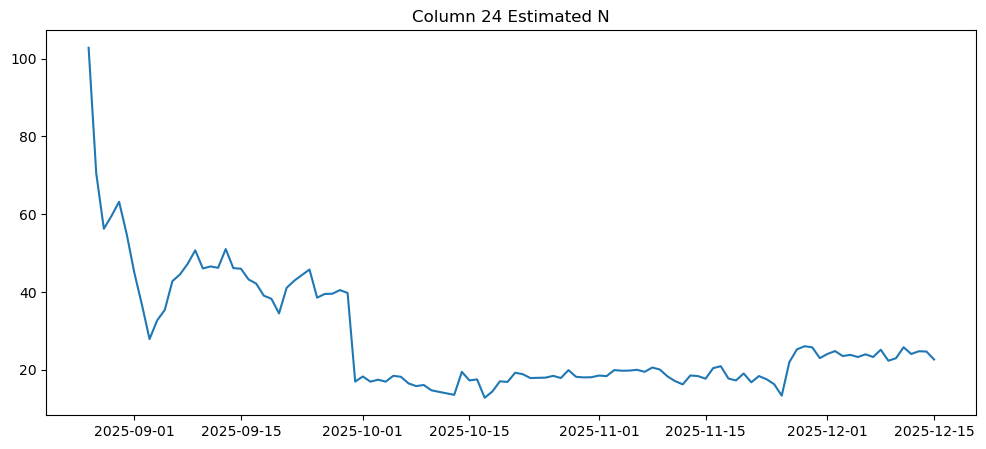

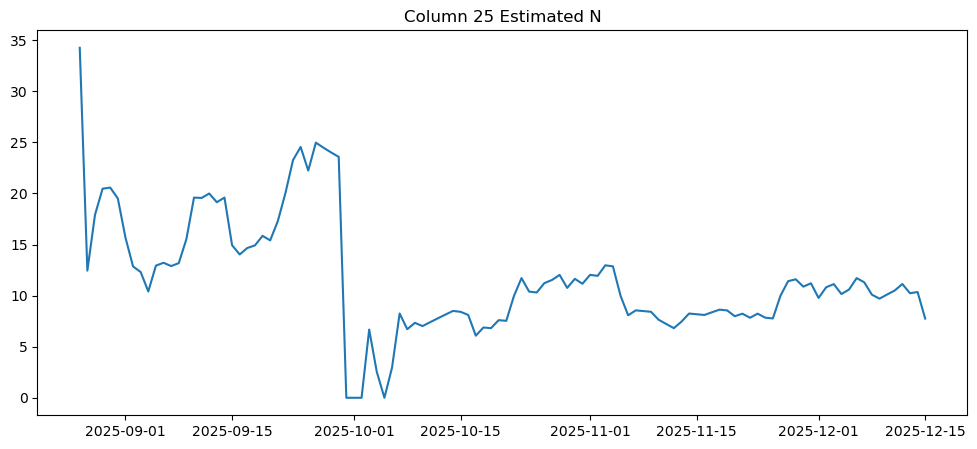

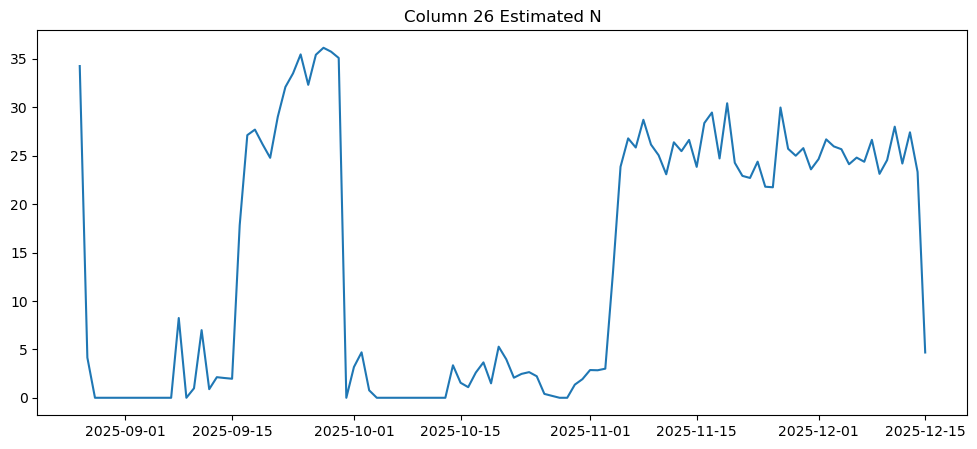

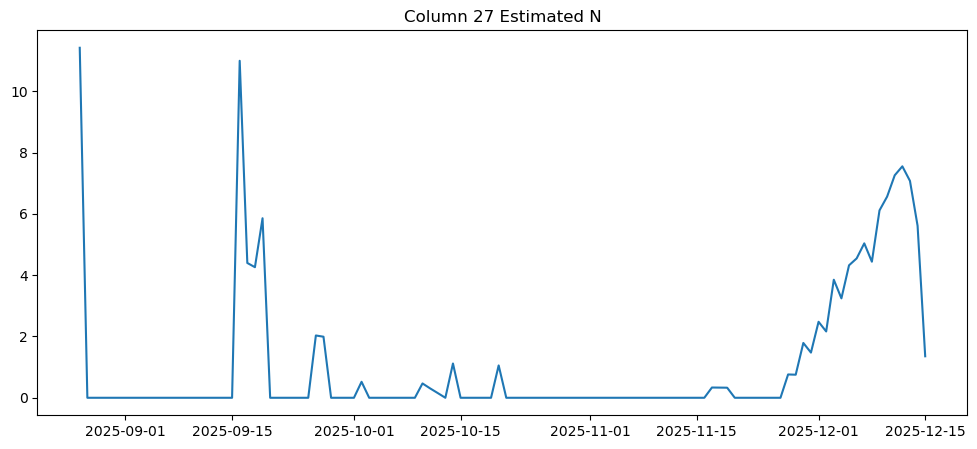

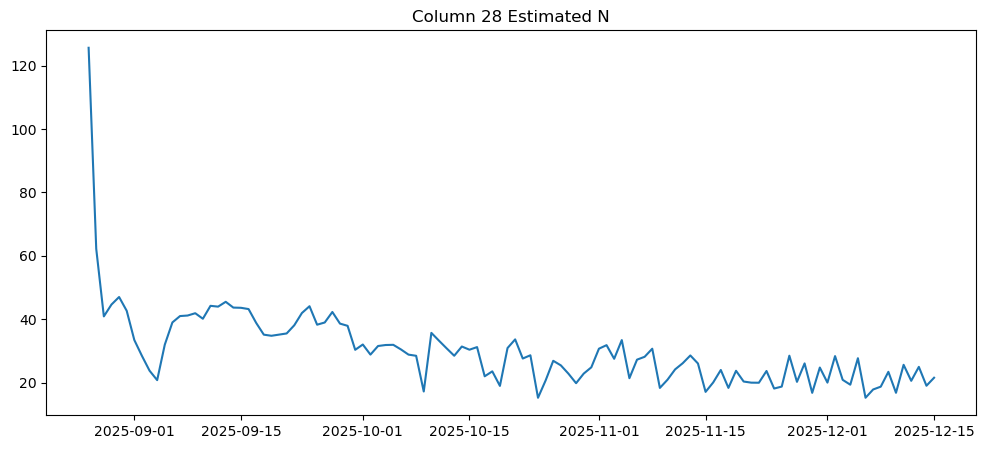

In [7]:
# col_number = 3

for col_number in range(1, 29):

    exp_df = df[['Age', col_number]].copy()

    exp_df['n_cal'] = exp_df[col_number].to_numpy() / food_df['food_e'].to_numpy()

    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 5))
    plt.plot(exp_df.index, exp_df['n_cal'])

    plt.title(f'Column {col_number} Estimated N')

    # 修改坐标轴
    plt.show()

## 2 单栏预测头数波动时间序列+异常事件点

In [8]:
import matplotlib.pyplot as plt
from matplotlib import font_manager
import matplotlib.dates as mdates

CN_font = font_manager.FontProperties(fname='C:/Windows/Fonts/simhei.ttf')

color_map_event = {
    1: 'green',
    2: 'red',
    3: 'orange',
    4: 'blue',
    # 5: '',
    9: 'black',
    -1: 'yellow',

}
type_map_event = {
    1: '发白',
    2: '呼吸道疾病',
    3: '应激（死亡）',
    4: '胀气',
    # 5: 'purple',
    9: '猝死',

    -1: '治疗'
}

In [ ]:
err_df = pd.read_excel('data/4栋2单元零星死亡数据.xlsx', index_col=False)

err_df = err_df[::-1].reset_index(drop=True)   # reverse date
err_df['Date'] = pd.to_datetime(err_df['Date'] )

err_mask = err_df['die_case'] >= 1
err_dates = pd.to_datetime(err_df.loc[err_mask, 'Date'])

#### 8-12月

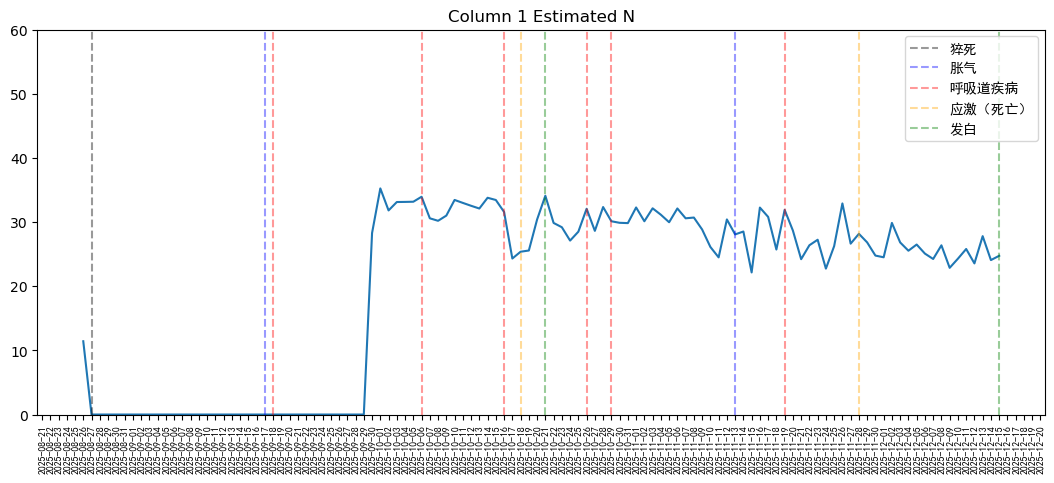

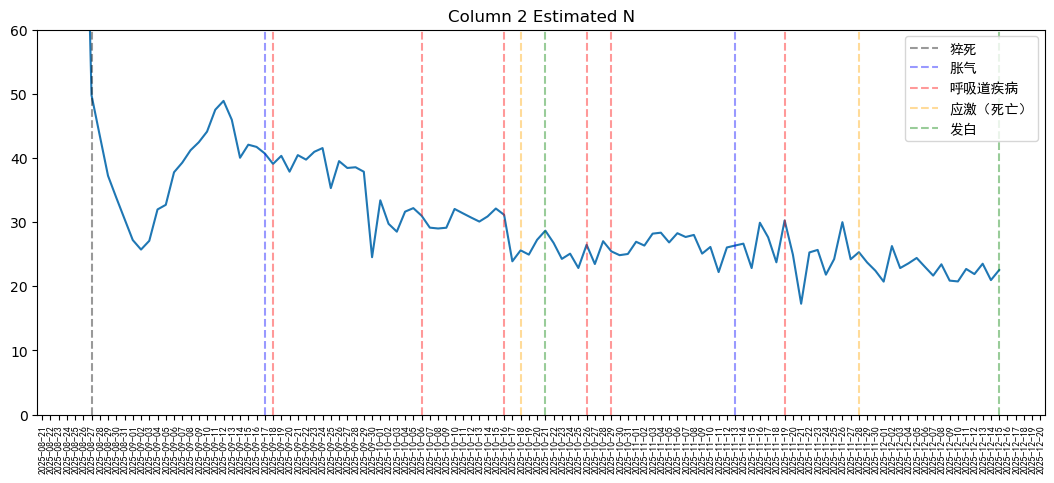

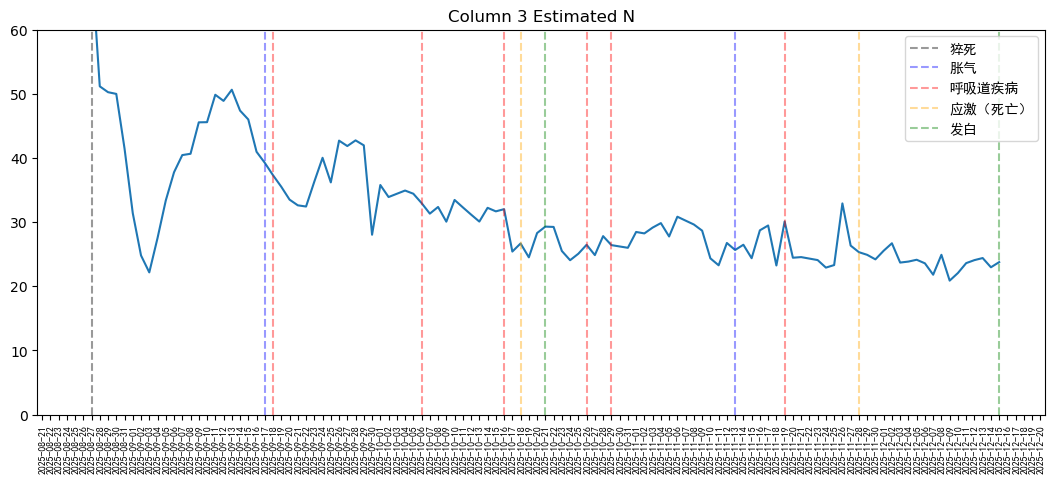

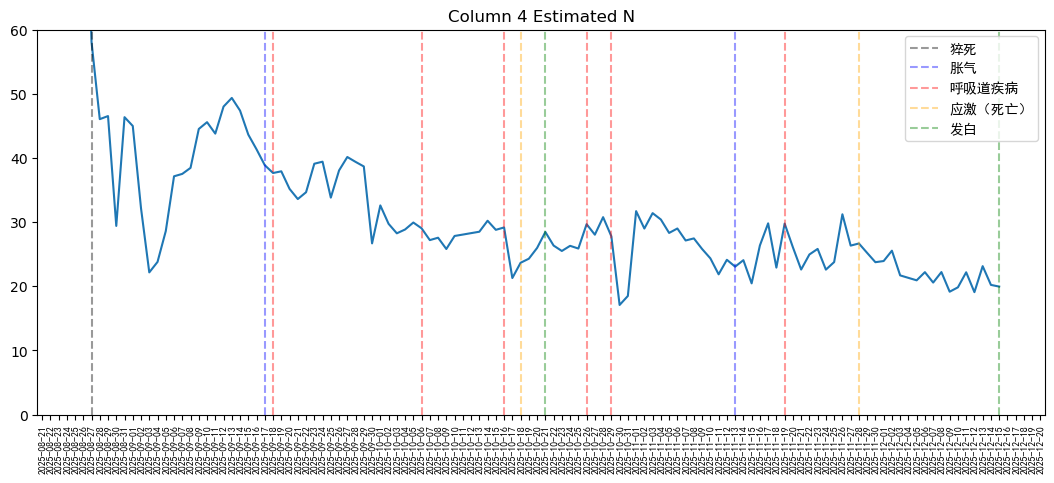

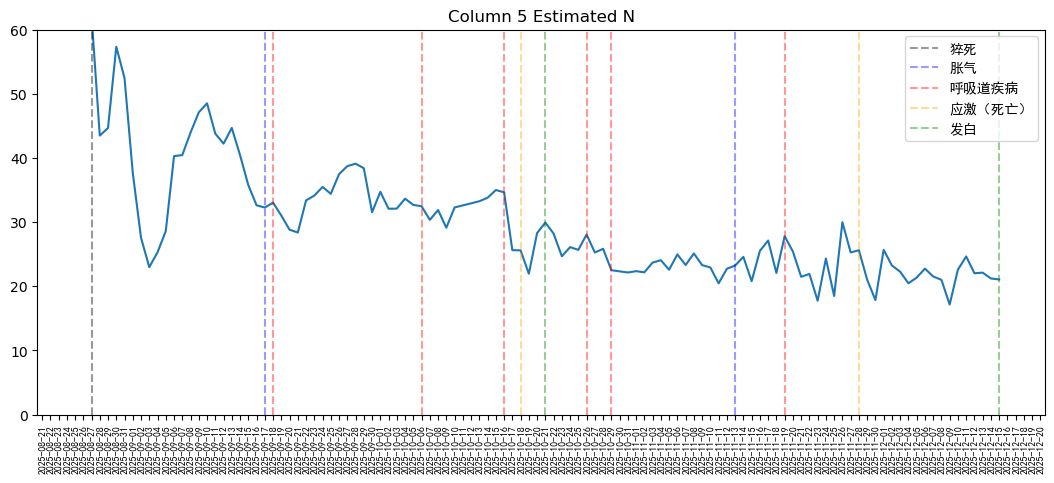

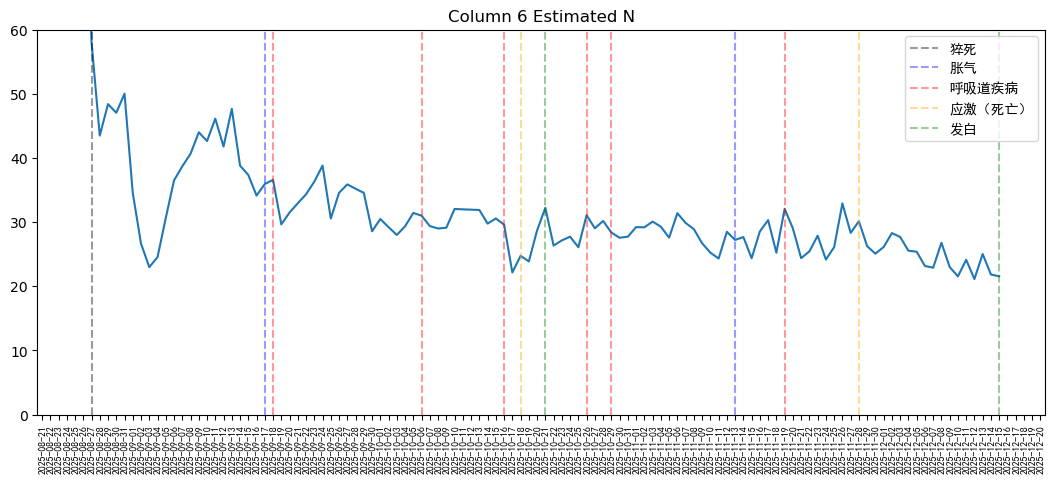

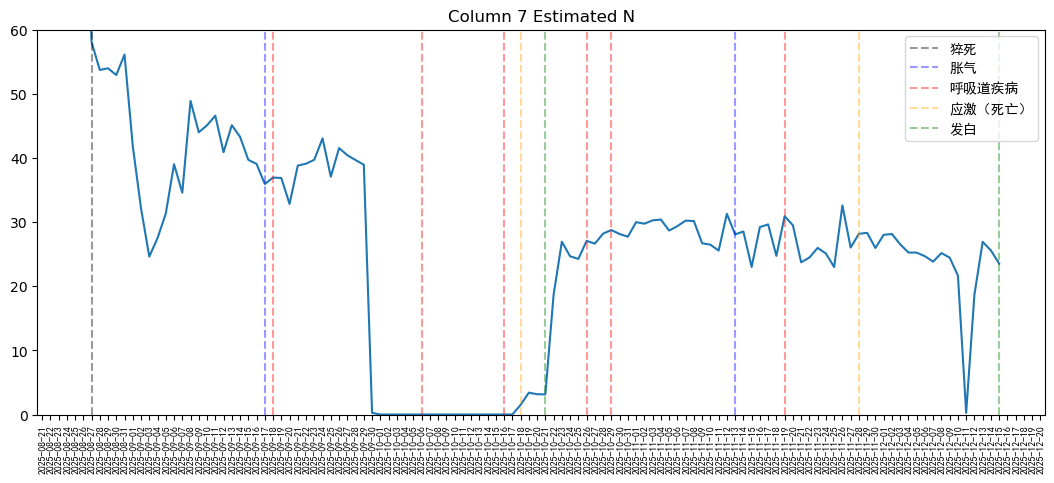

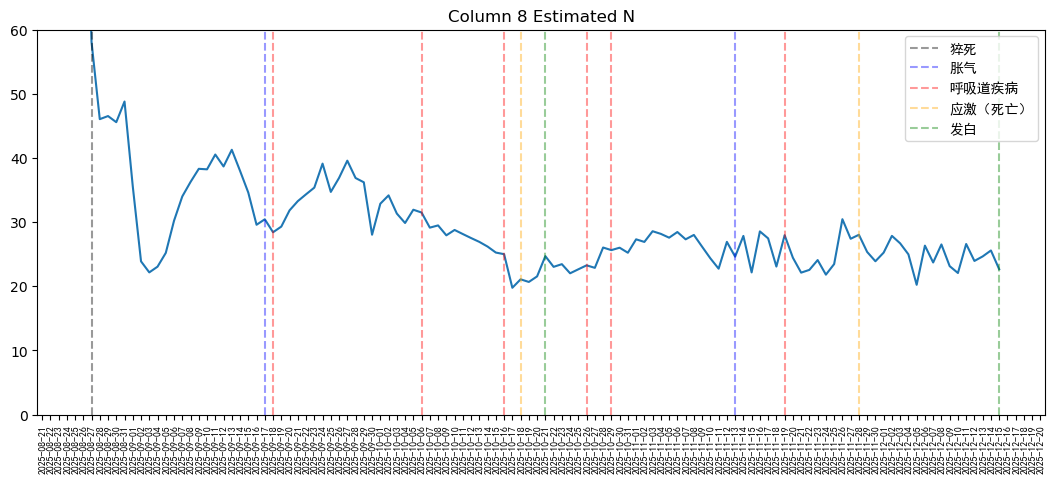

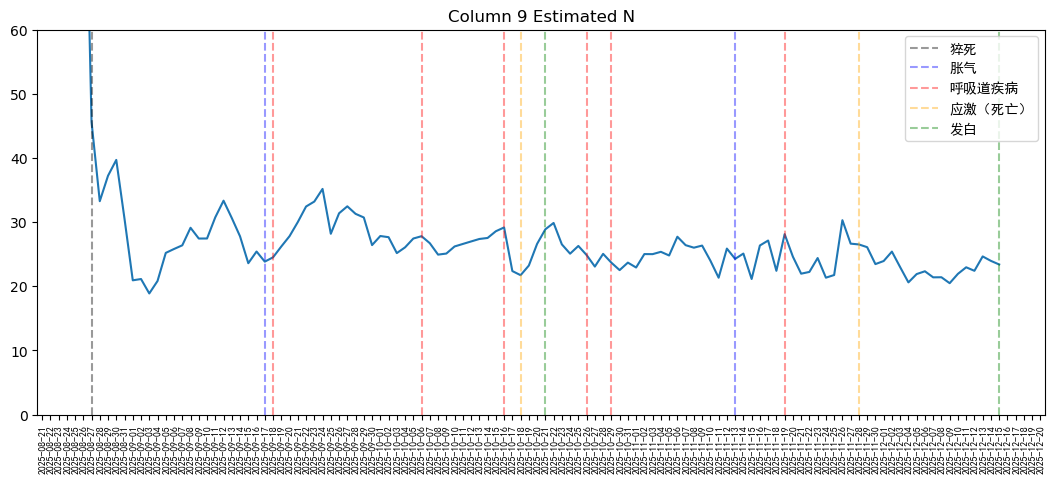

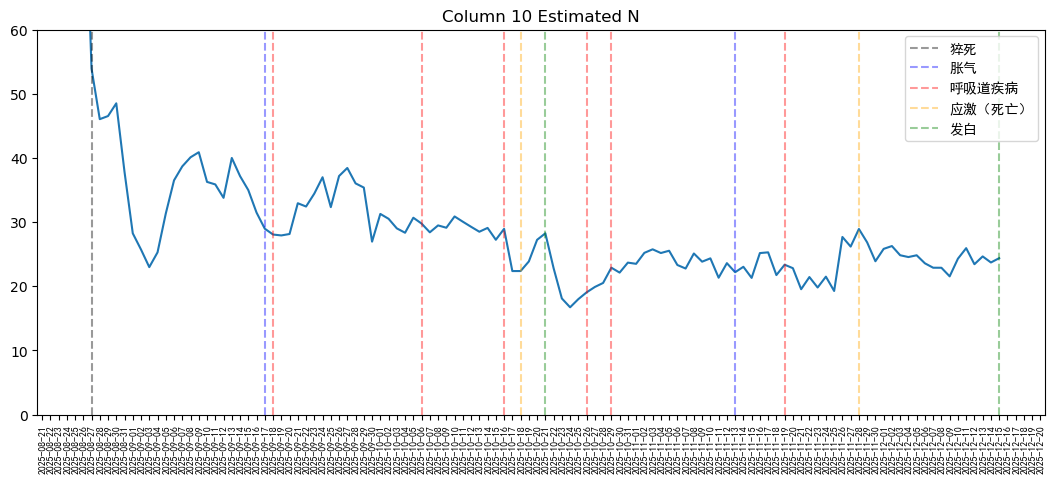

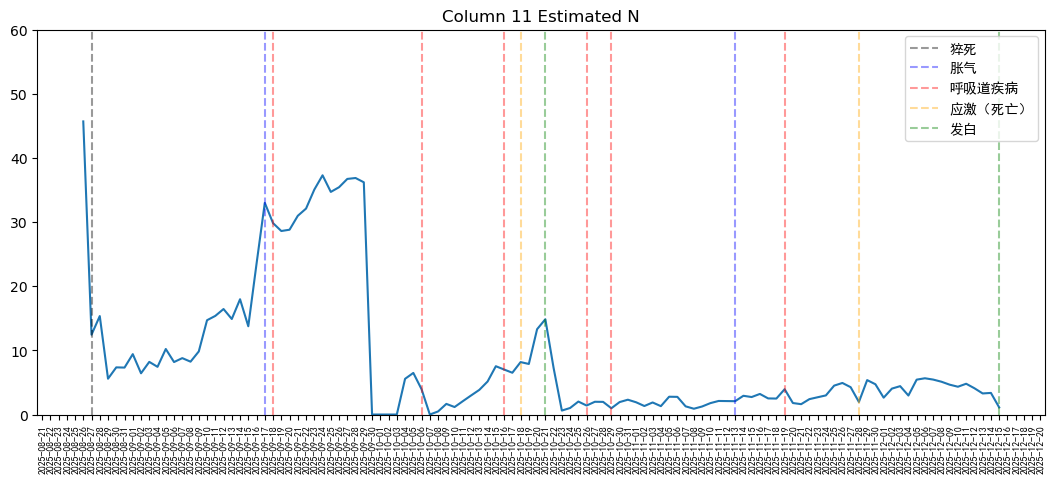

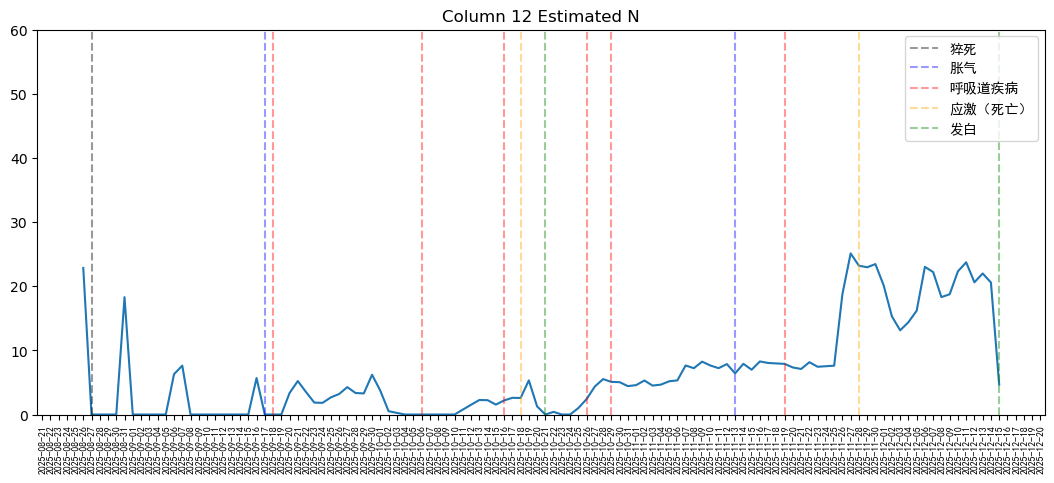

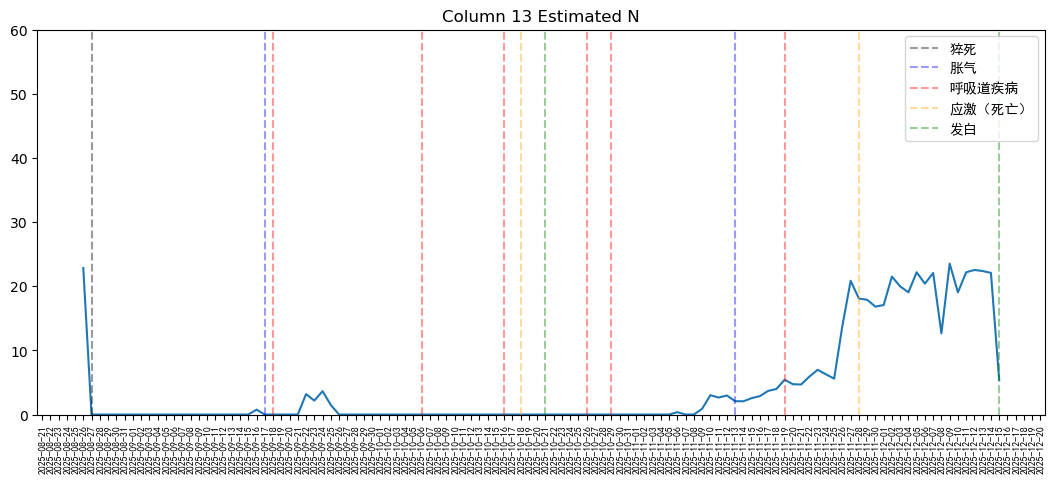

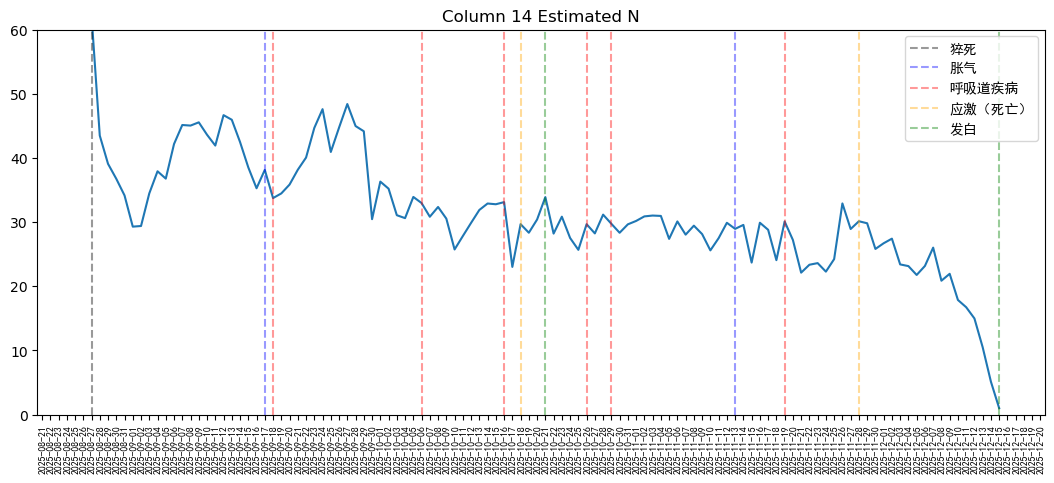

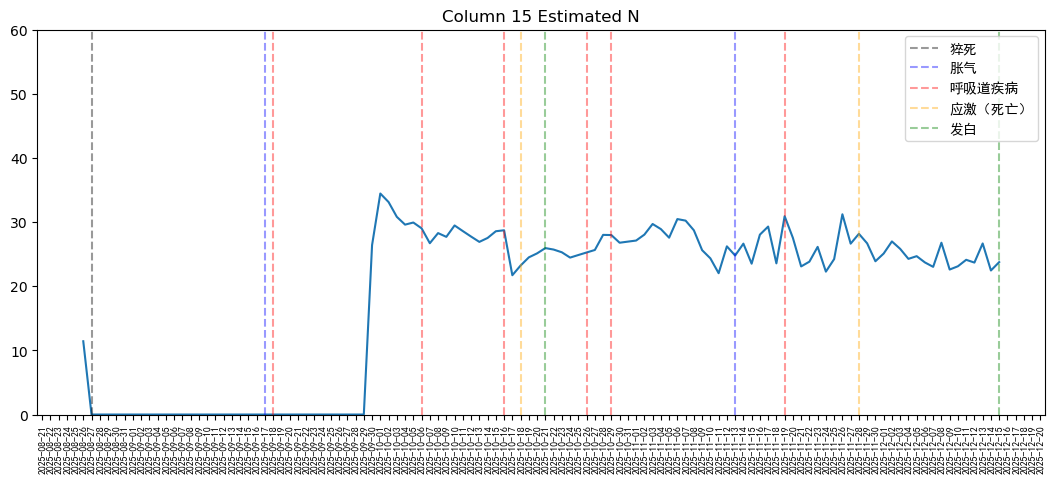

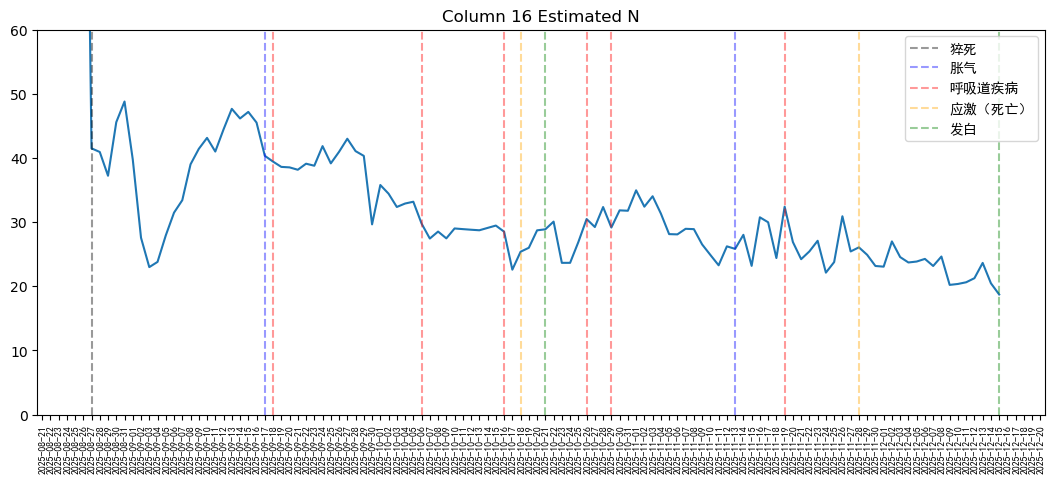

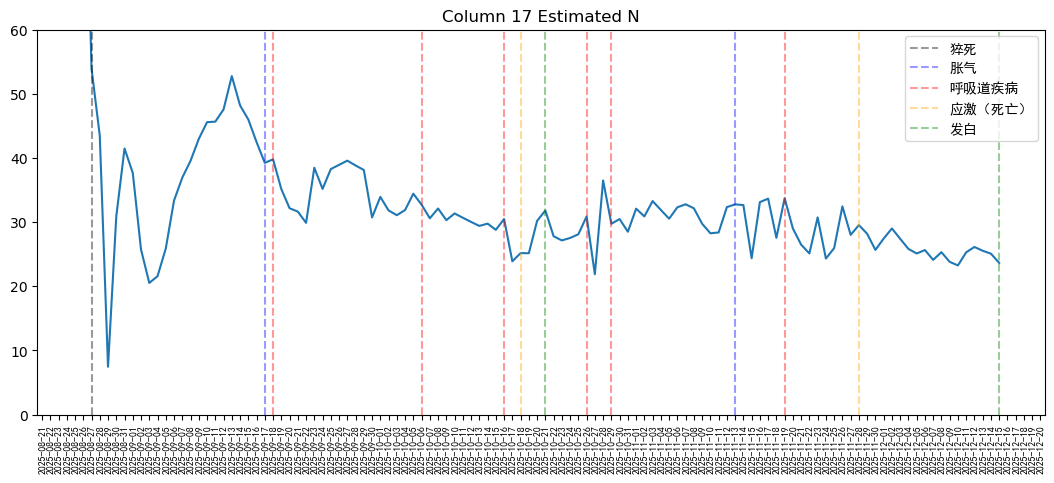

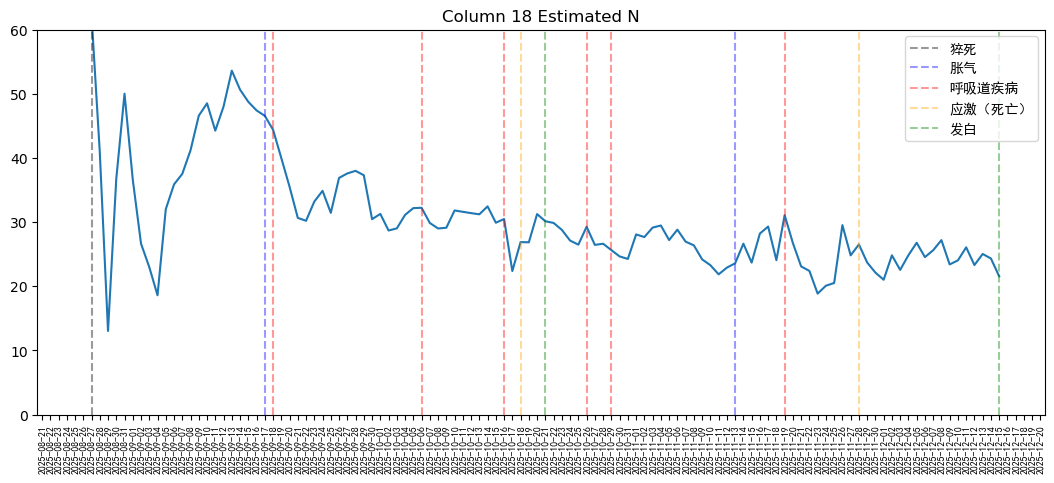

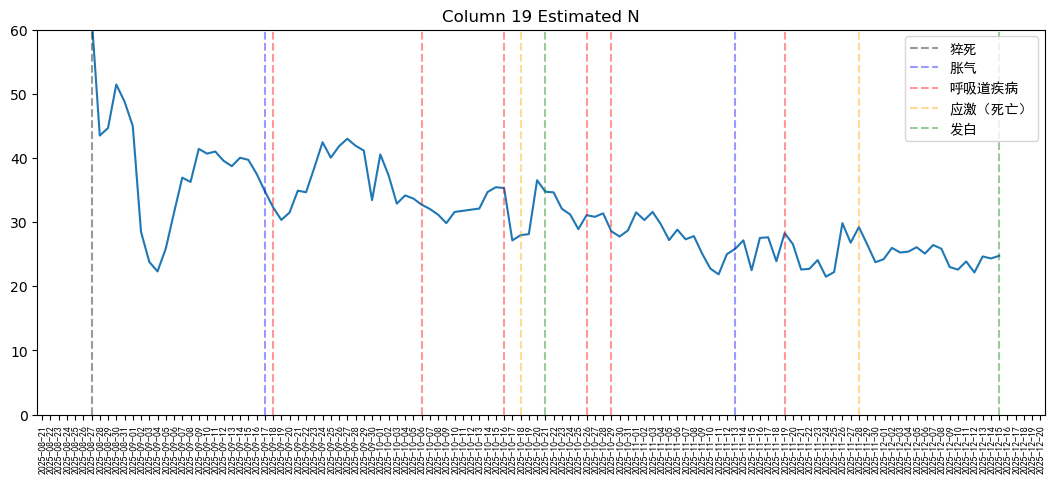

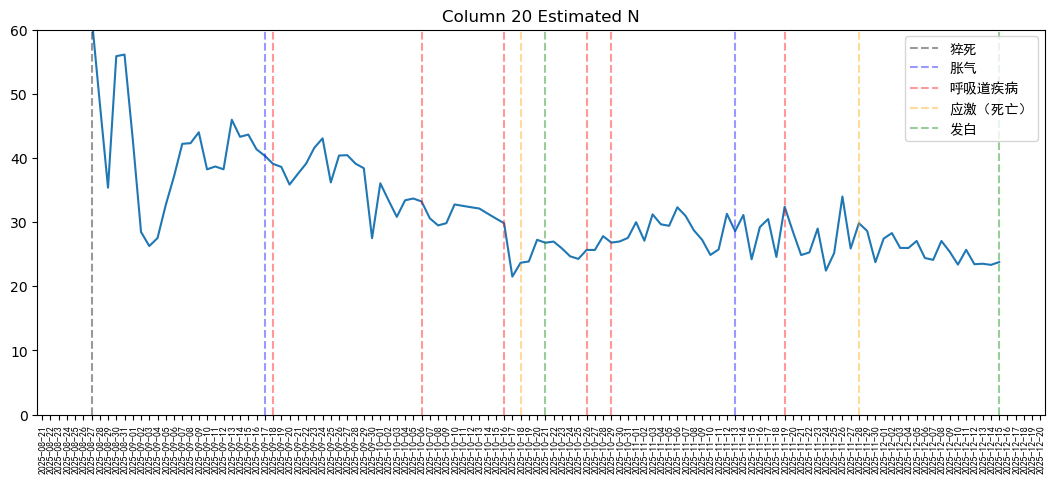

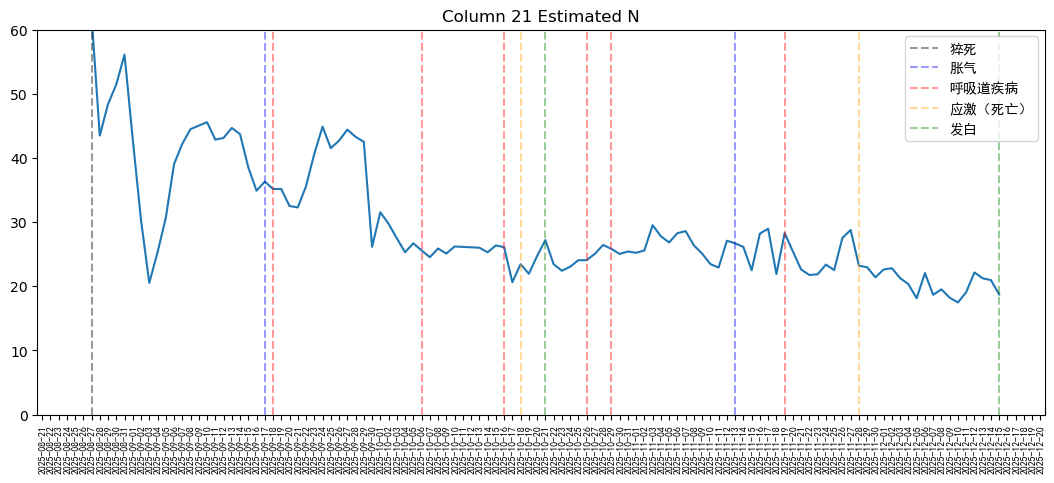

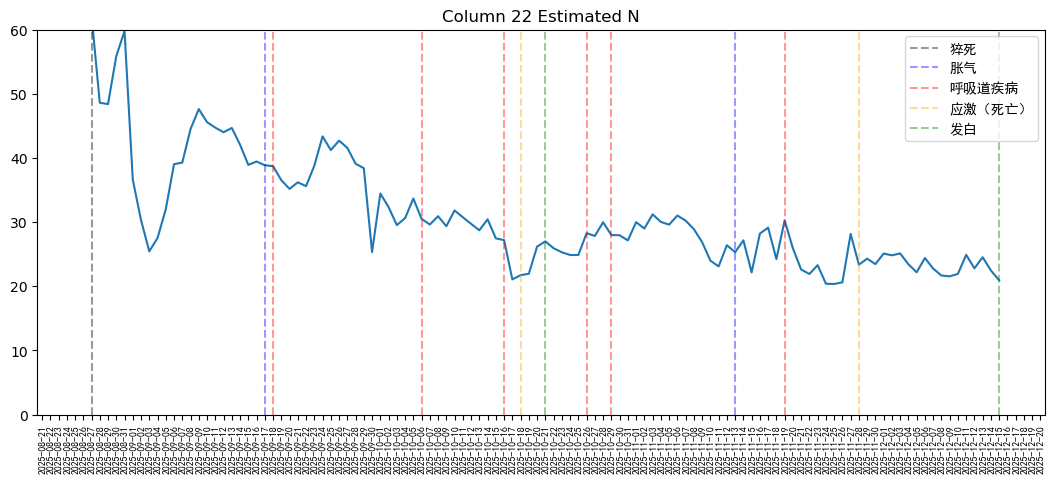

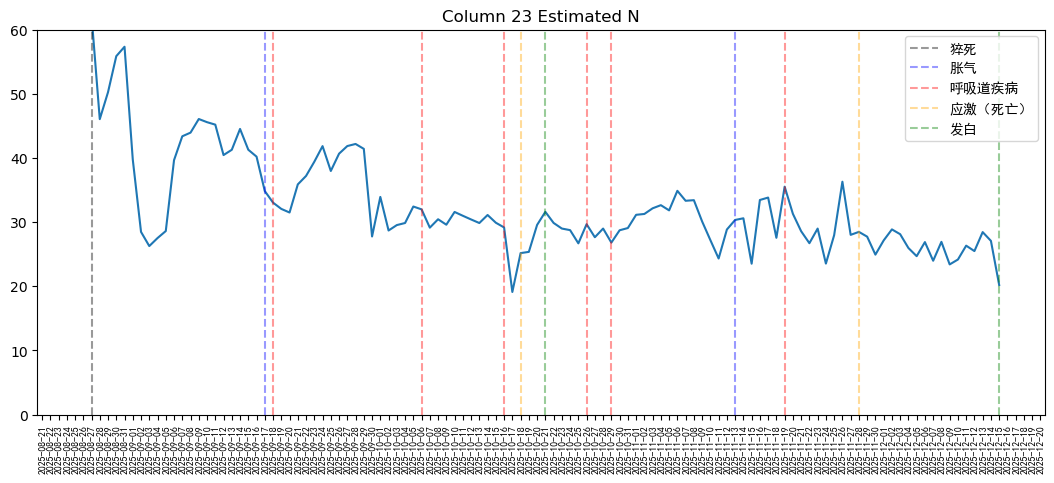

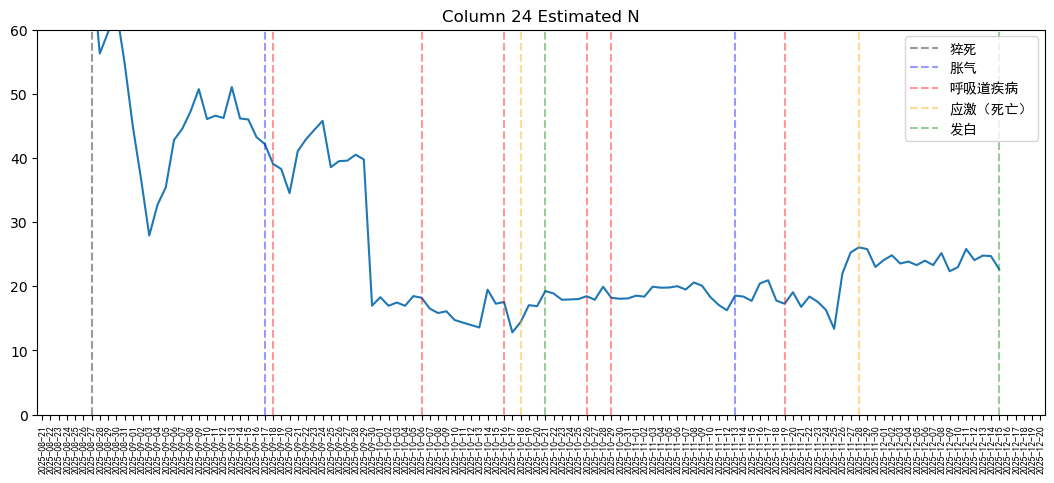

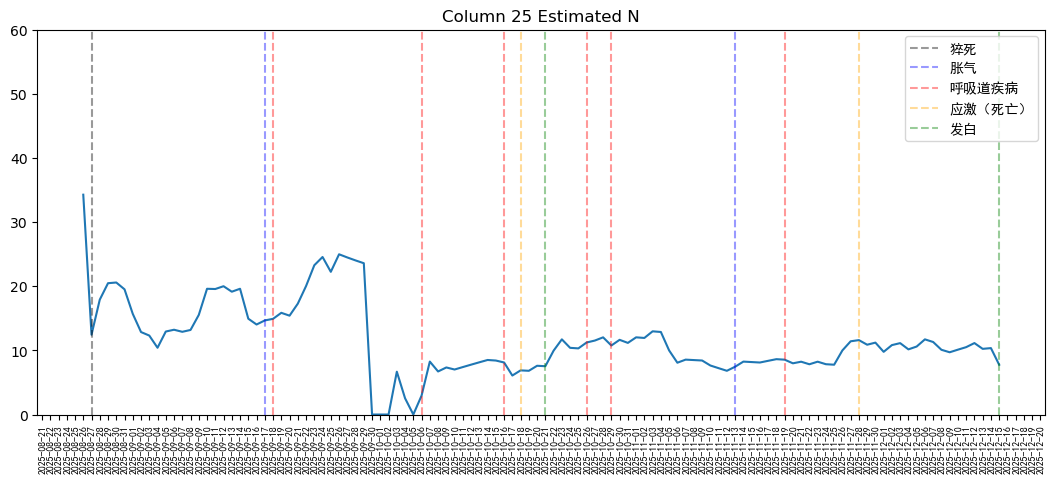

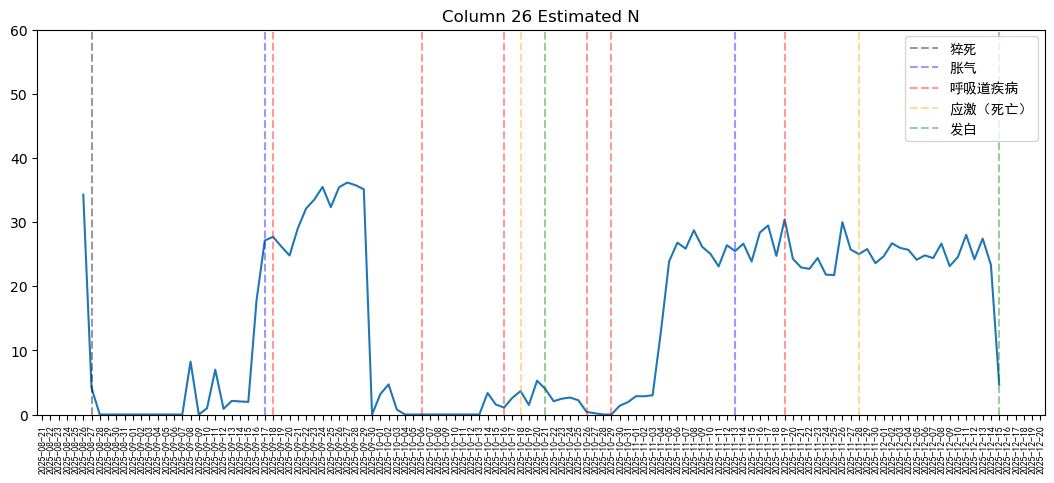

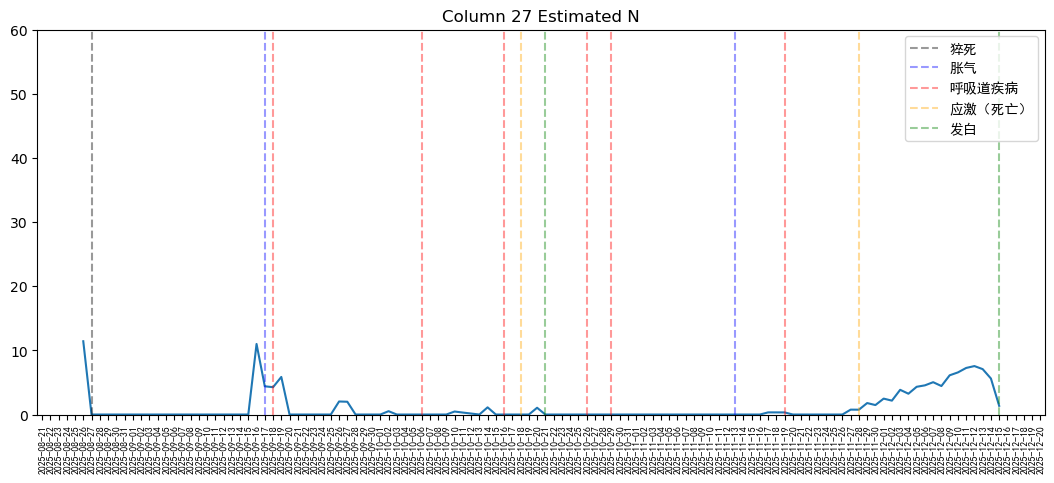

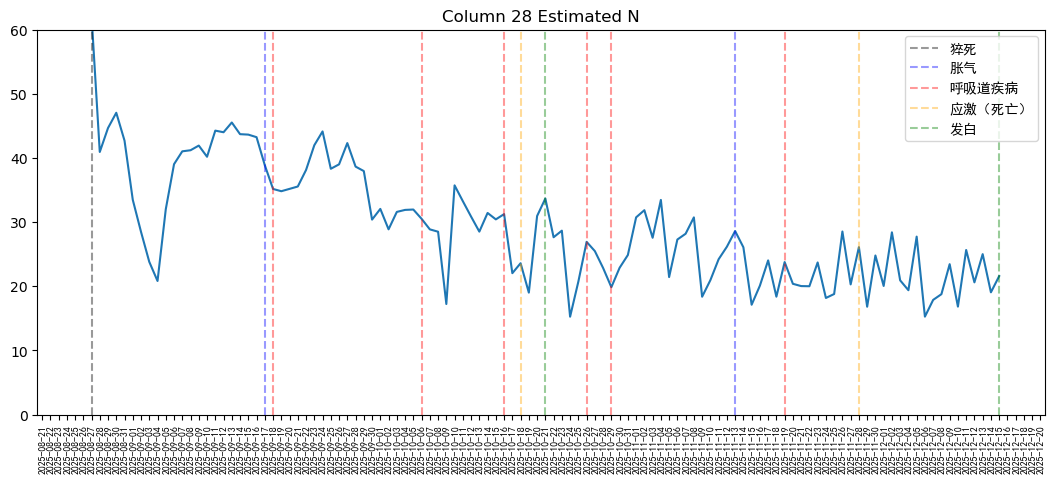

In [10]:
for col_number in range(1, 29):

    exp_df = df[['Age', col_number]].copy()

    exp_df['n_cal'] = exp_df[col_number].to_numpy() / food_df['food_e'].to_numpy()

    # N 值计算曲线
    plt.figure(figsize=(13, 5))
    plt.plot(exp_df.index, exp_df['n_cal'])

    # 事件曲线
    used_label = set()

    for date in err_dates:
        event_type = err_df.loc[err_df['Date'] == date, 'err_type'].iloc[0] # int
        color = color_map_event[event_type]
        event_label = type_map_event[event_type] if type_map_event[event_type] not in used_label else None
        used_label.add(event_label)

        plt.axvline(date, linestyle='--', color = color, alpha=0.4,
                    label = event_label)

    # 图细节
    
    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.xticks(rotation=90, fontproperties=CN_font, fontsize=7)
    plt.ylim(0, 60)
    plt.title(f'Column {col_number} Estimated N')
    plt.legend(prop = CN_font, loc='upper right')
    plt.show()

#### 10-12月

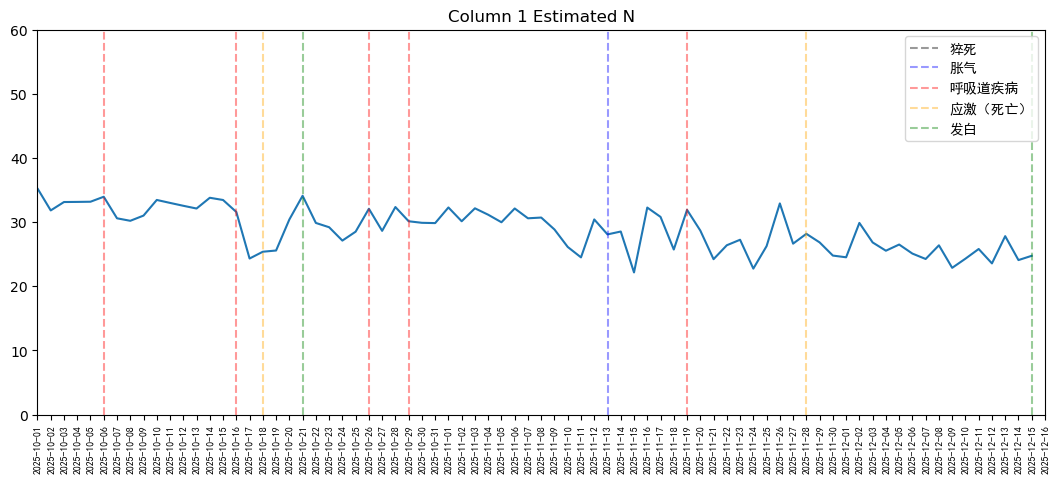

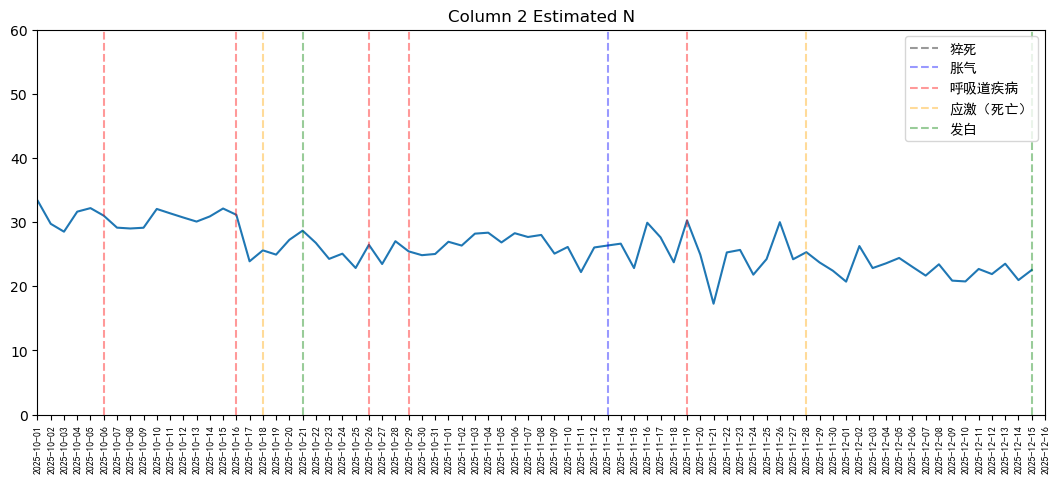

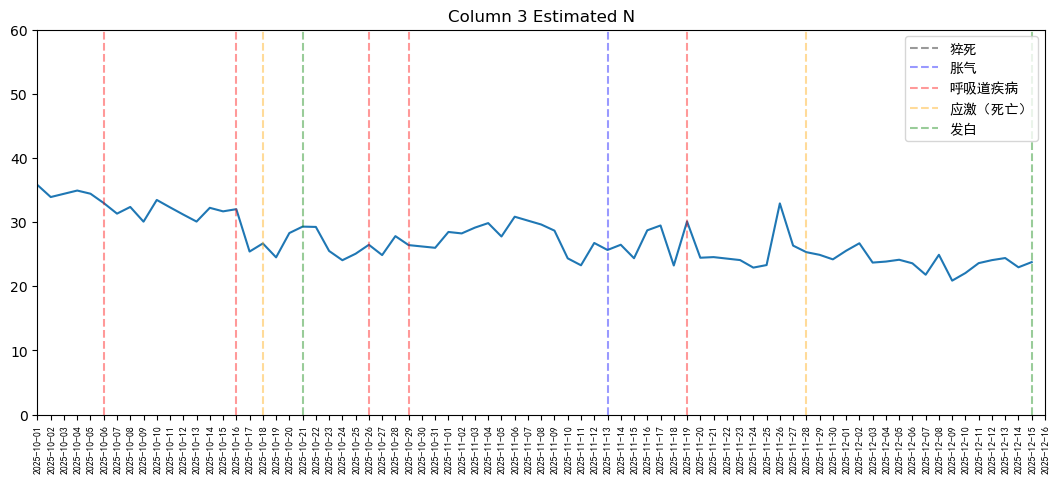

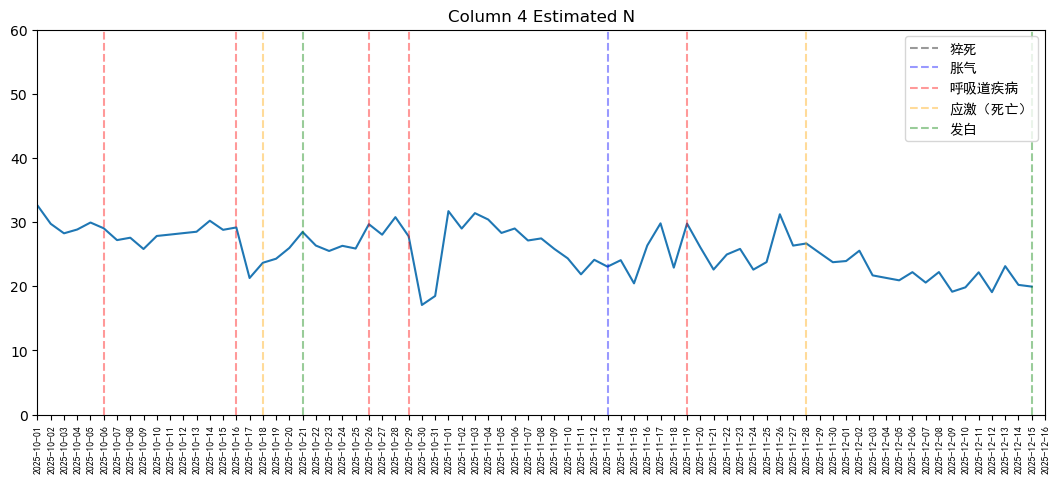

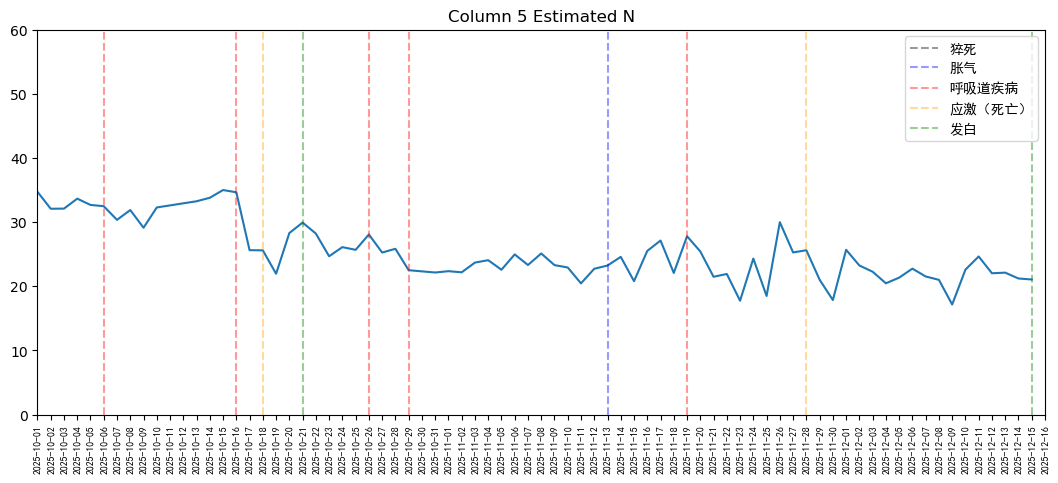

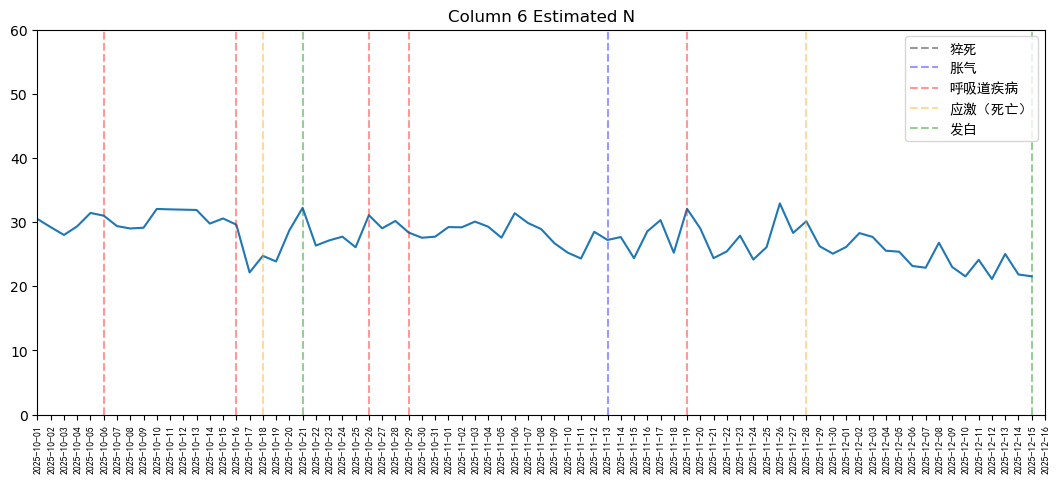

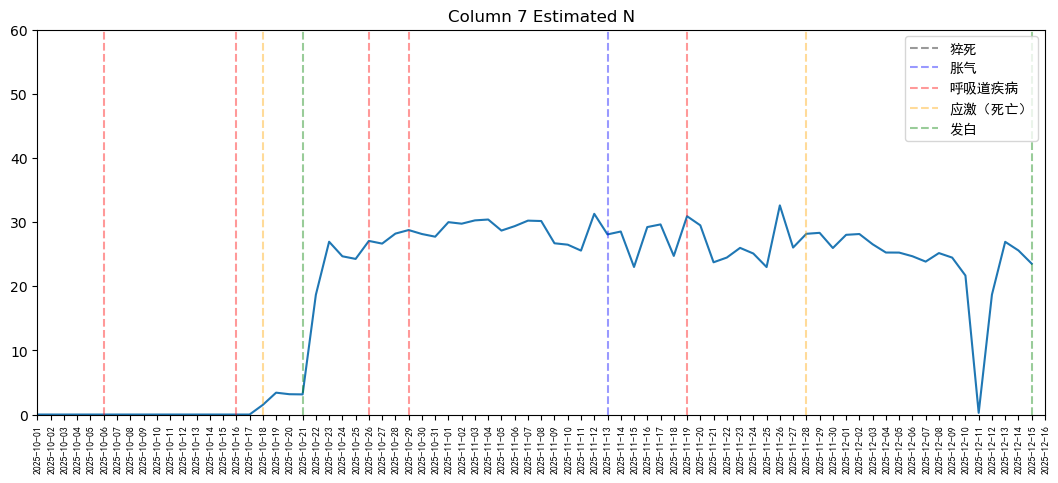

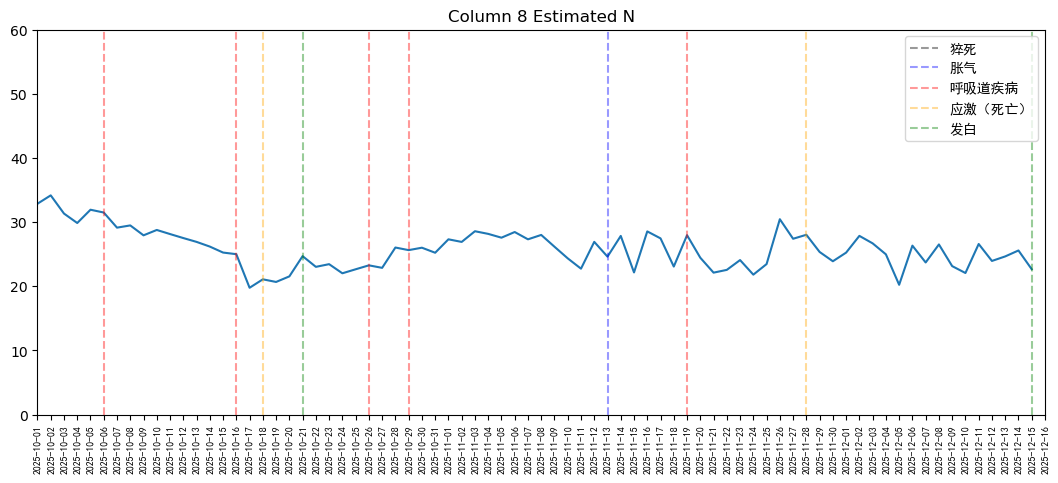

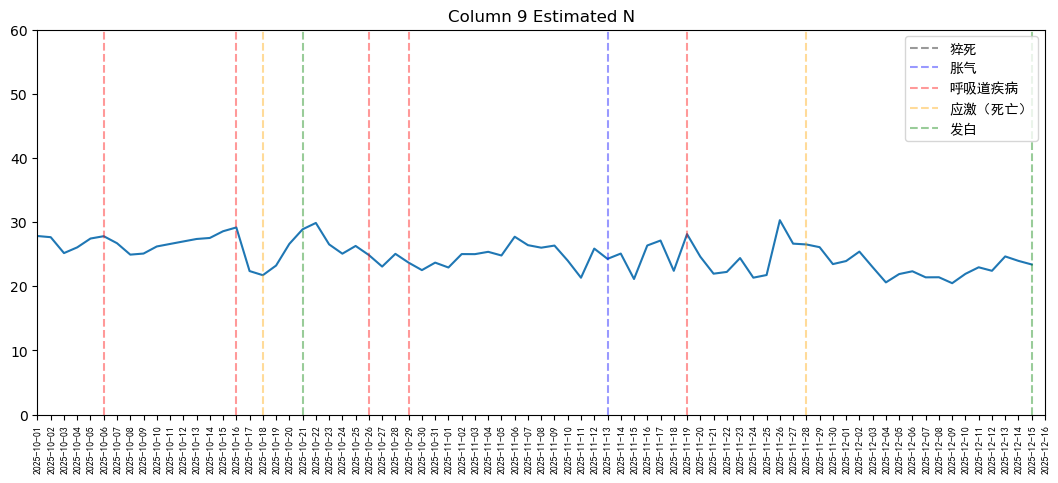

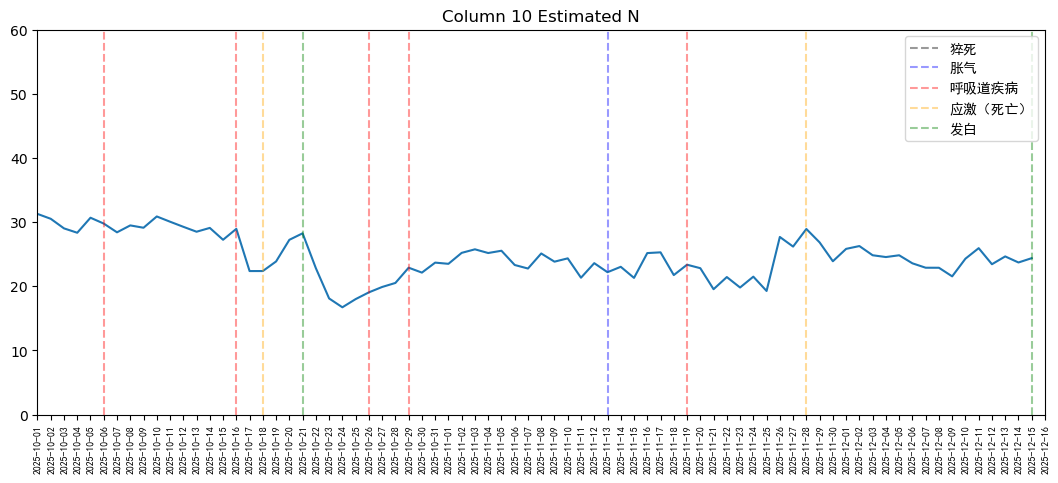

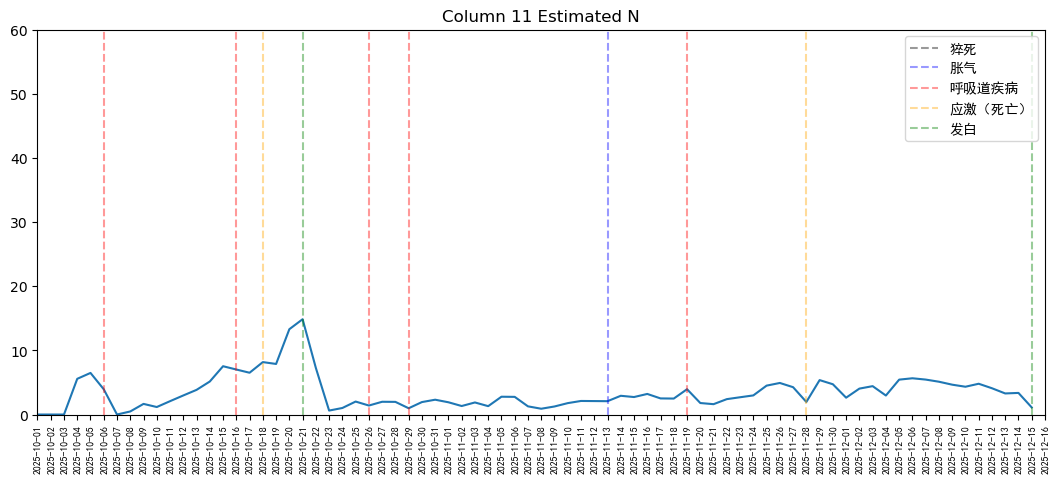

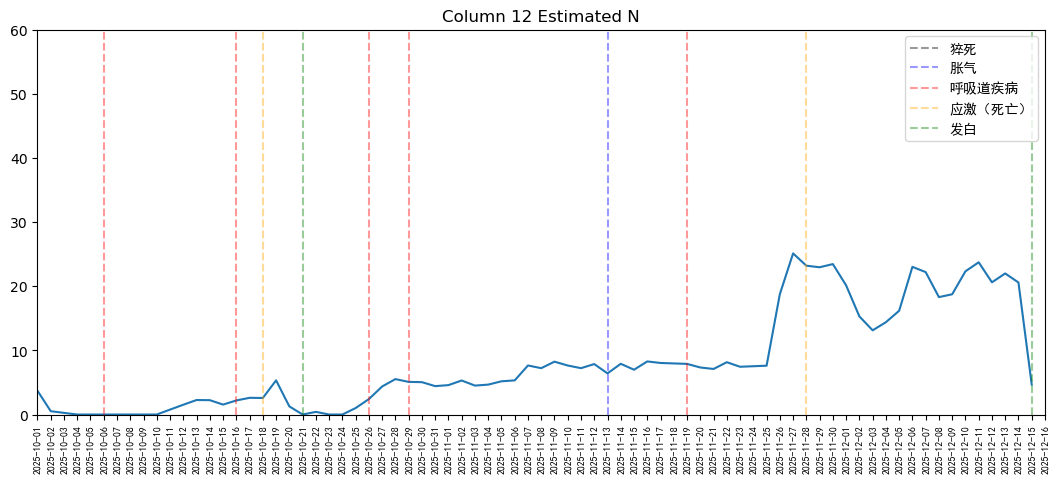

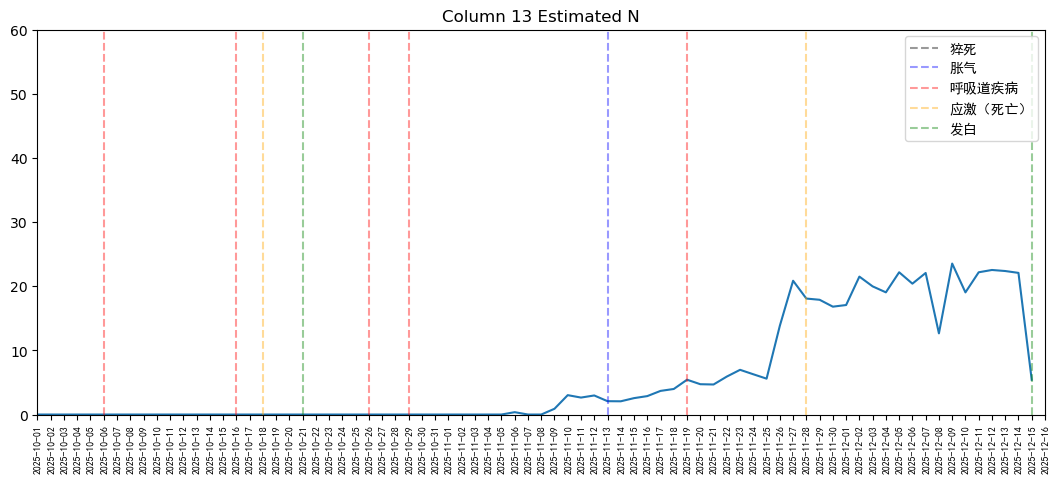

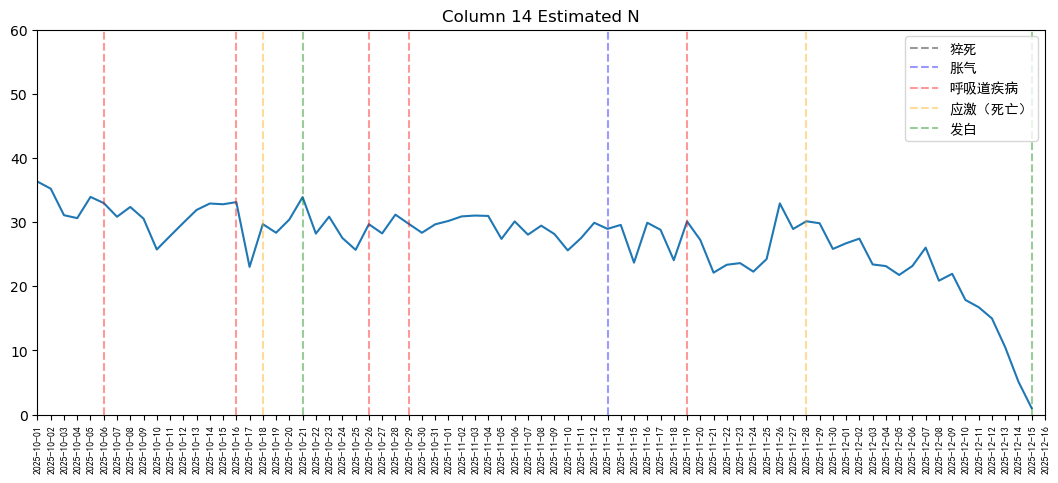

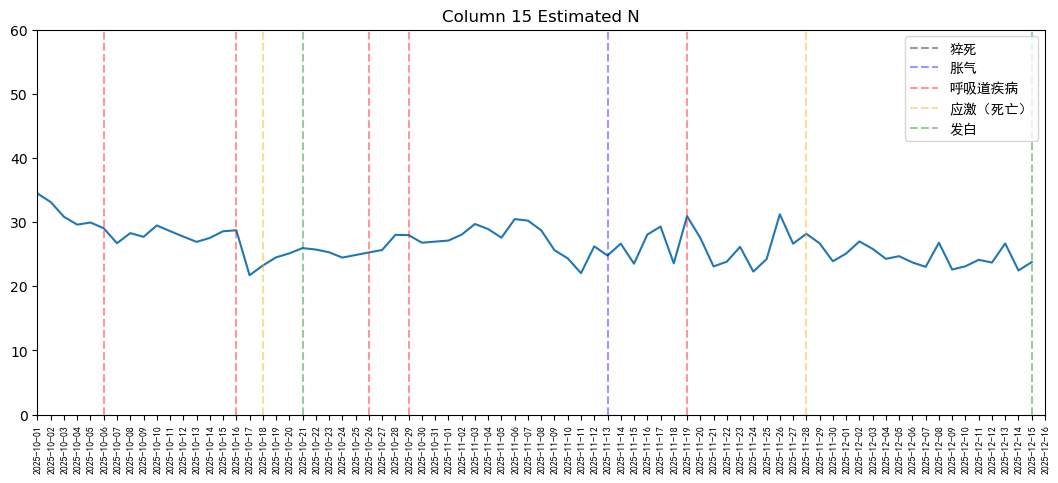

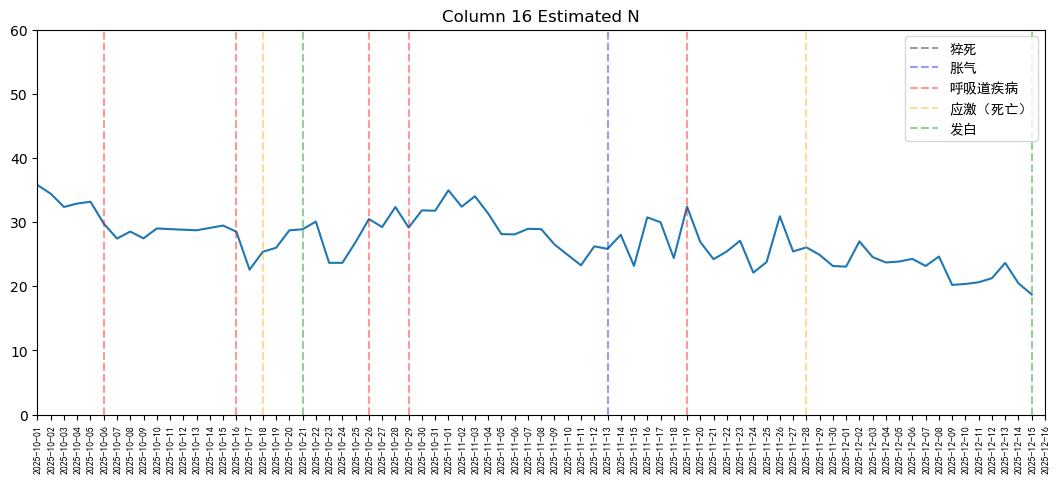

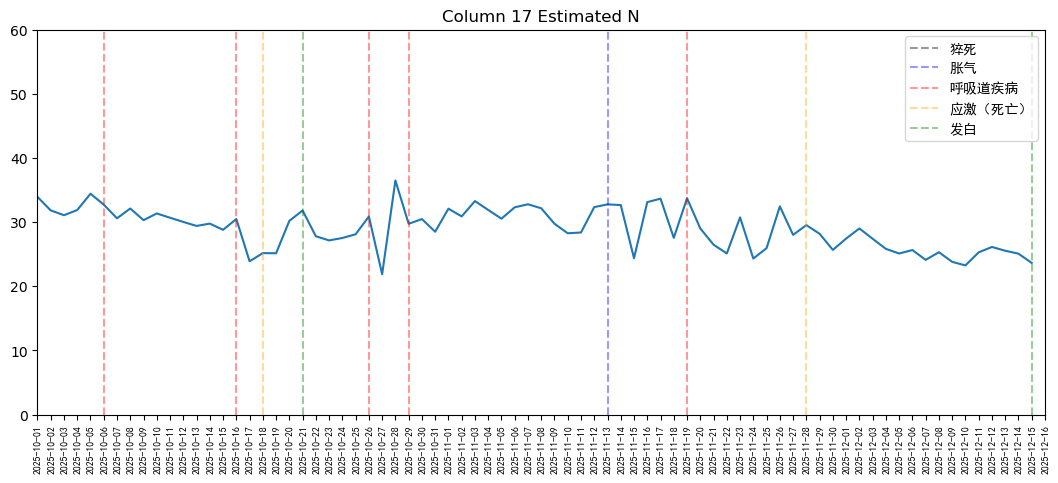

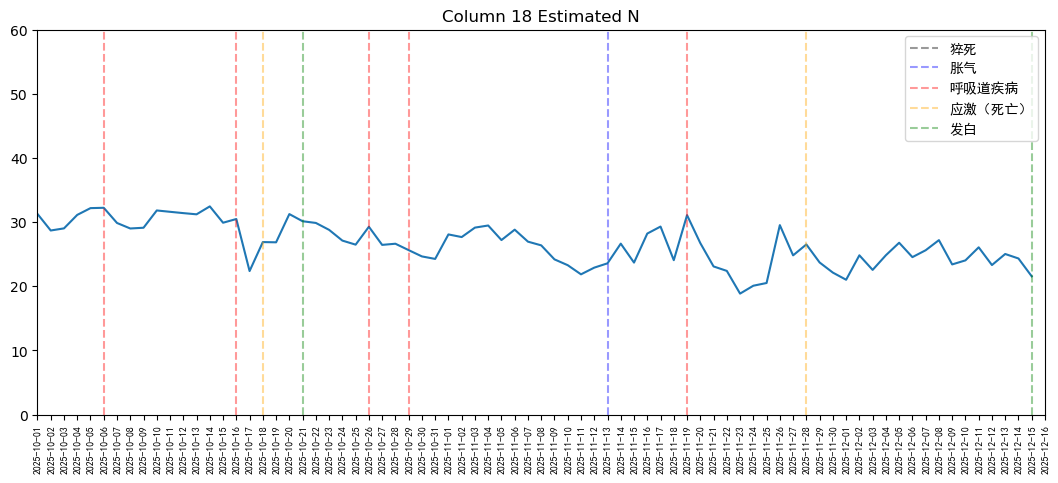

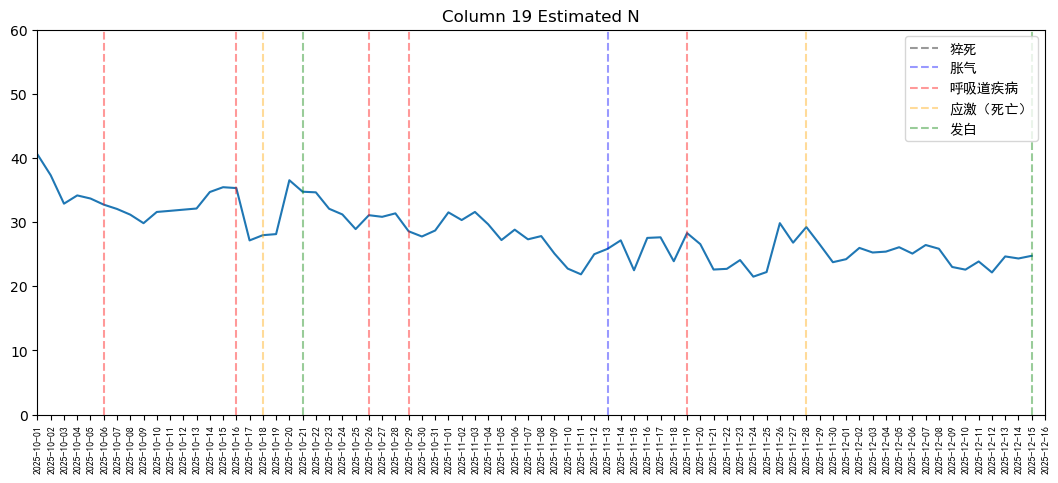

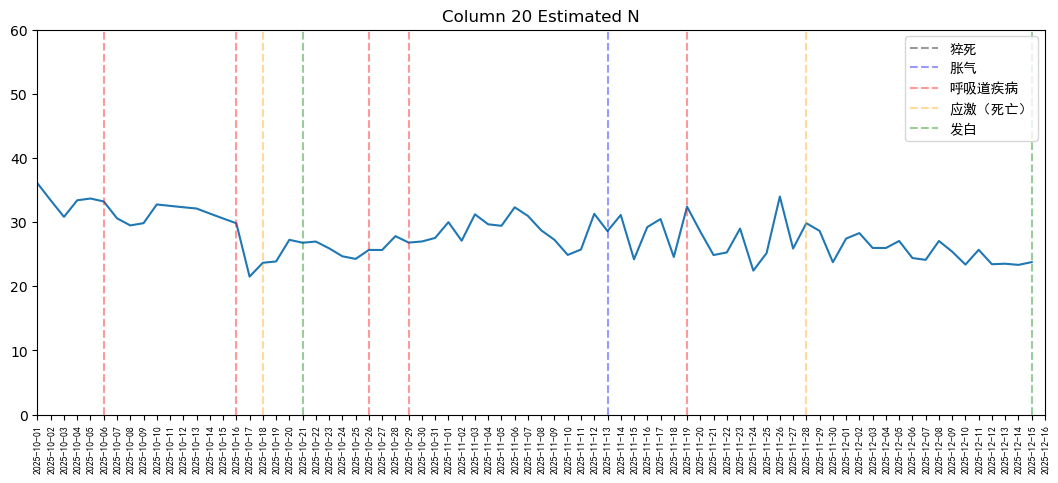

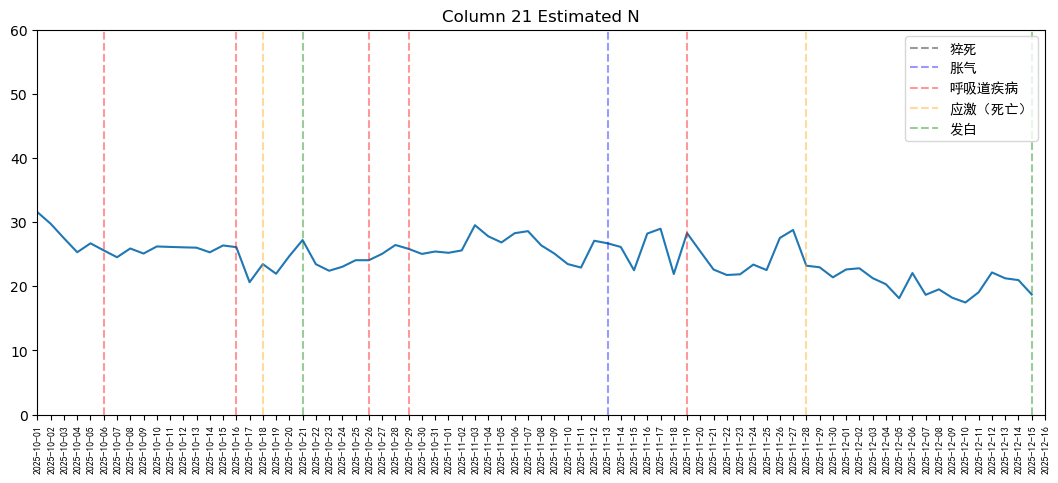

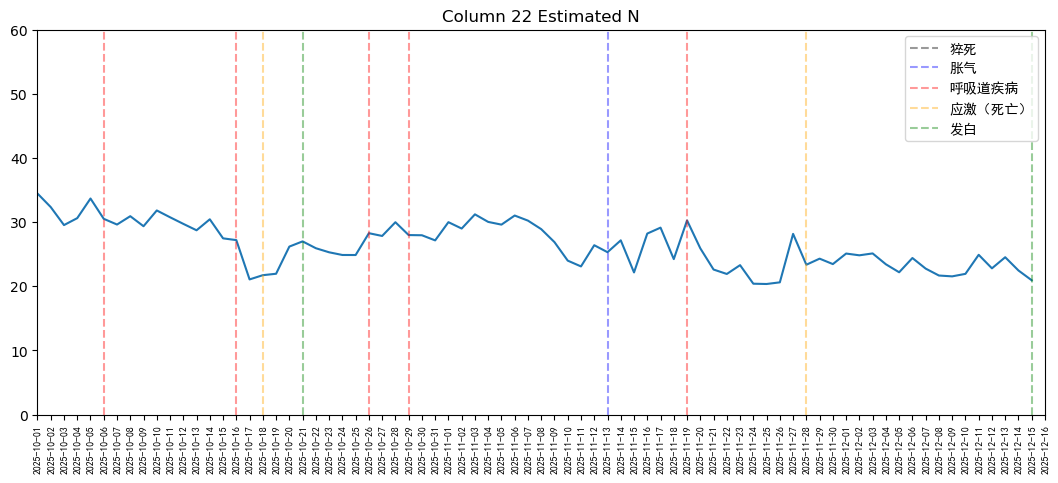

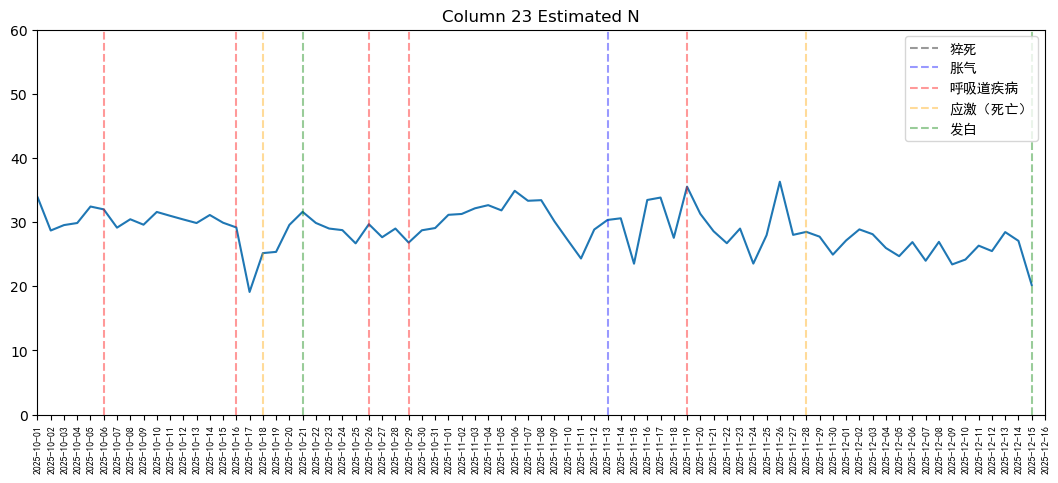

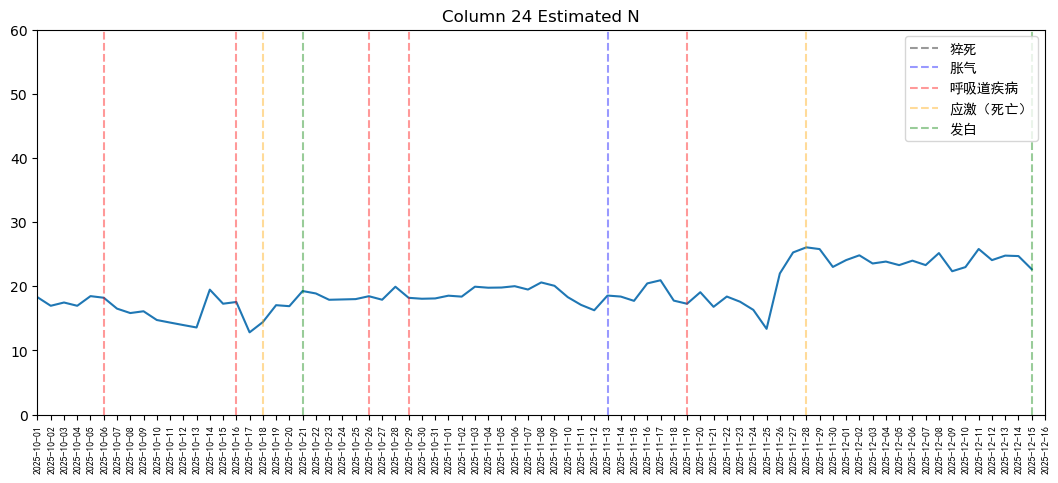

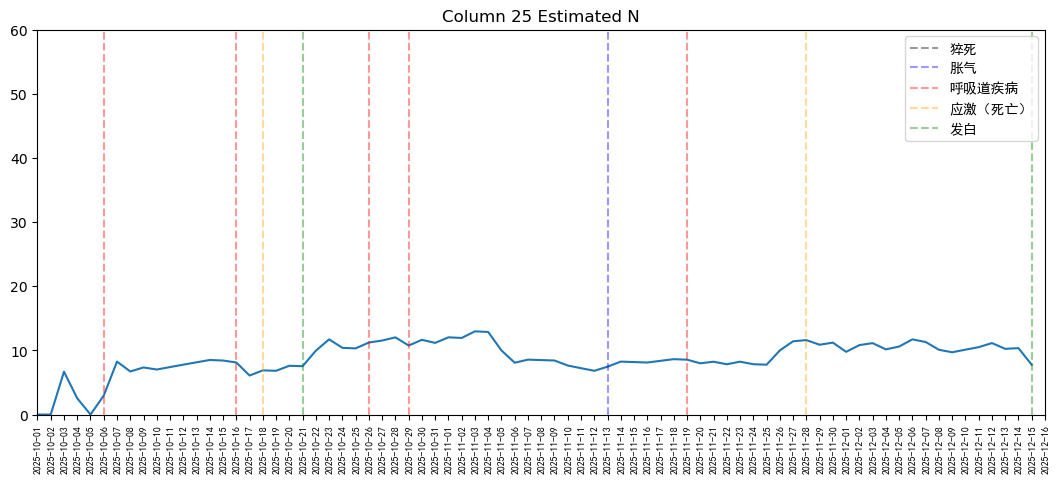

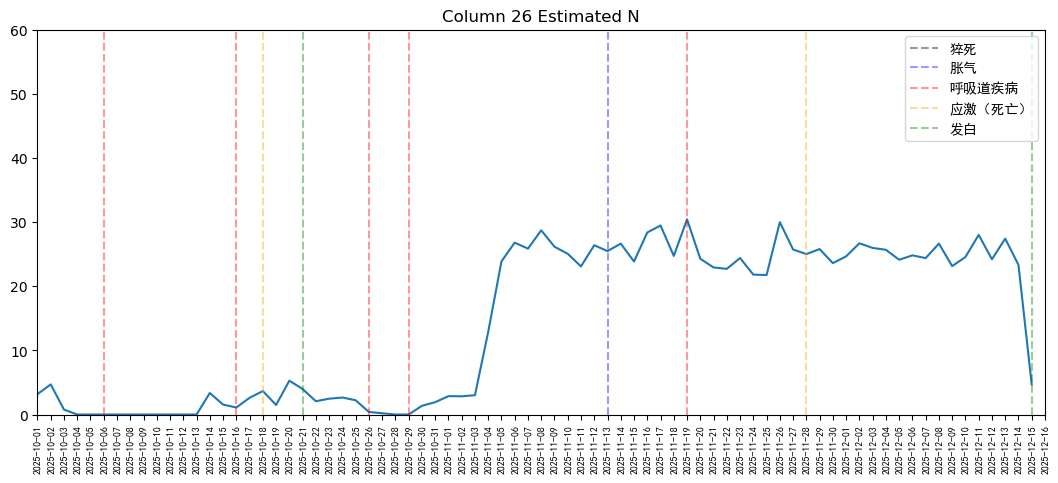

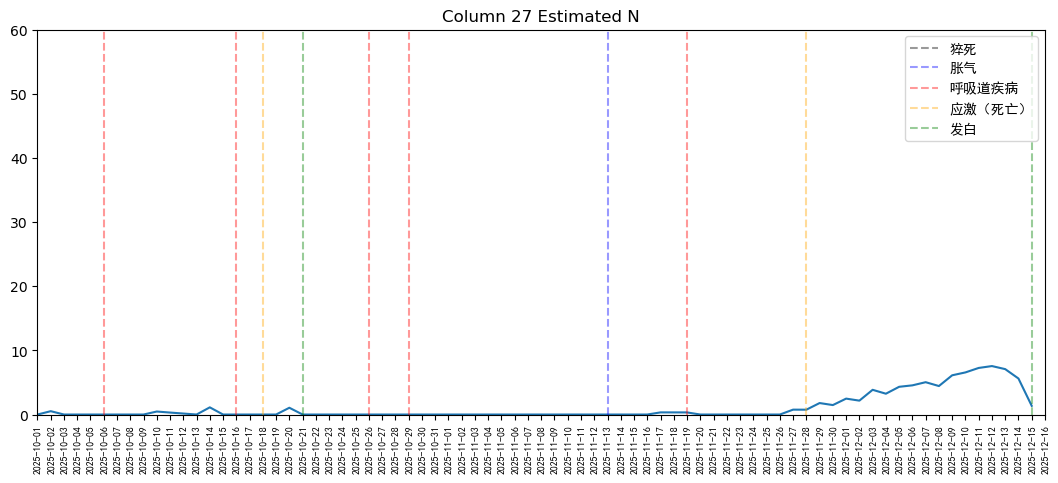

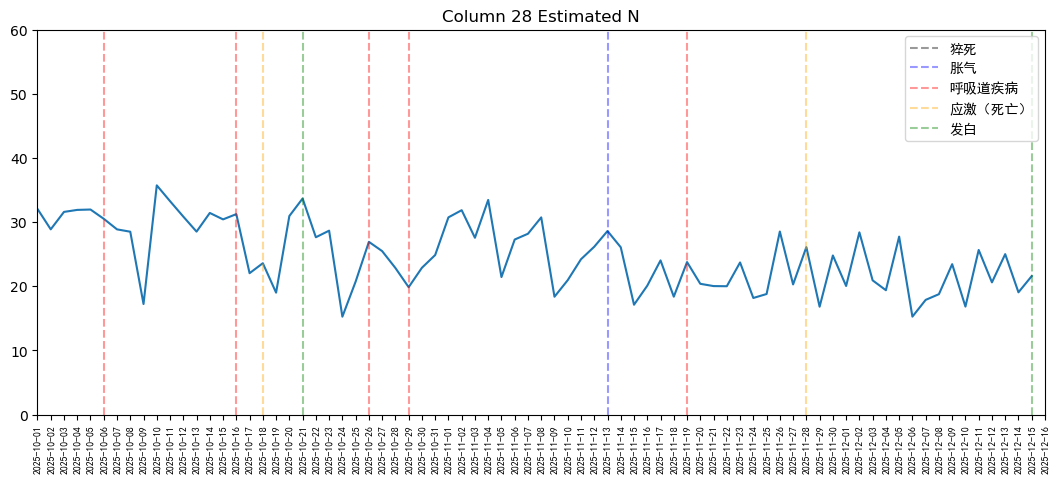

In [11]:
for col_number in range(1, 29):

    exp_df = df[['Age', col_number]].copy()

    exp_df['n_cal'] = exp_df[col_number].to_numpy() / food_df['food_e'].to_numpy()

    # N 值计算曲线
    plt.figure(figsize=(13, 5))
    plt.plot(exp_df.index, exp_df['n_cal'])

    # 事件曲线
    used_label = set()

    for date in err_dates:
        event_type = err_df.loc[err_df['Date'] == date, 'err_type'].iloc[0] # int
        color = color_map_event[event_type]
        event_label = type_map_event[event_type] if type_map_event[event_type] not in used_label else None
        used_label.add(event_label)

        plt.axvline(date, linestyle='--', color = color, alpha=0.4,
                    label = event_label)

    # 图细节
    
    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.xticks(rotation=90, fontproperties=CN_font, fontsize=7)
    plt.ylim(0, 60)
    plt.xlim(pd.to_datetime(['2025-10-01', '2025-12-16']))
    plt.title(f'Column {col_number} Estimated N')
    plt.legend(prop = CN_font, loc='upper right')
    plt.show()

## 3 28栏变化量可视化

#### 8-12月

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
import matplotlib.dates as mdates

CN_font = font_manager.FontProperties(fname='C:/Windows/Fonts/simhei.ttf')

color_map_event = {
    1: 'green',
    2: 'red',
    3: 'orange',
    4: 'blue',
    # 5: '',
    9: 'black',
    -1: 'yellow',

}
type_map_event = {
    1: '发白',
    2: '呼吸道疾病',
    3: '应激（死亡 ）',
    4: '胀气',
    # 5: 'purple',
    9: '猝死',

    -1: '治疗'
}

In [ ]:
# Event Data
err_df = pd.read_excel('data/4栋2单元零星死亡数据.xlsx', index_col=False)

err_df = err_df[::-1].reset_index(drop=True)   # reverse date
err_df['Date'] = pd.to_datetime(err_df['Date'] )

err_mask = err_df['die_case'] >= 1
err_dates = pd.to_datetime(err_df.loc[err_mask, 'Date'])

In [14]:
# Change Data
import pandas as pd
import numpy as np

chg_df = pd.read_excel('data/V2-12.12-采食分析-育肥4-2单元饲喂记录-2025-08-25--2025-12-16.xlsx', sheet_name='子表3-对比前三天均值', index_col=False, na_values=['nan', 'NaN', 'NULL', ''])  # 子表2-对比前第3天
chg_df = chg_df.rename(columns={'日期': 'Date'})
chg_df['Date'] = pd.to_datetime(chg_df['Date'], format='%Y-%m-%d')
# 删除全空行
chg_df = chg_df[3:]
# chg_df = chg_df.dropna(how='all')

In [15]:
import matplotlib.pyplot as plt
import numpy as np

df_num = chg_df.iloc[:, 1:].apply(pd.to_numeric, errors='coerce')
df_num = df_num.fillna(float('inf'))

df_num.index = chg_df['Date']

df_num = df_num.T
# df_num.insert(0, 'Date', chg_df['Date'])

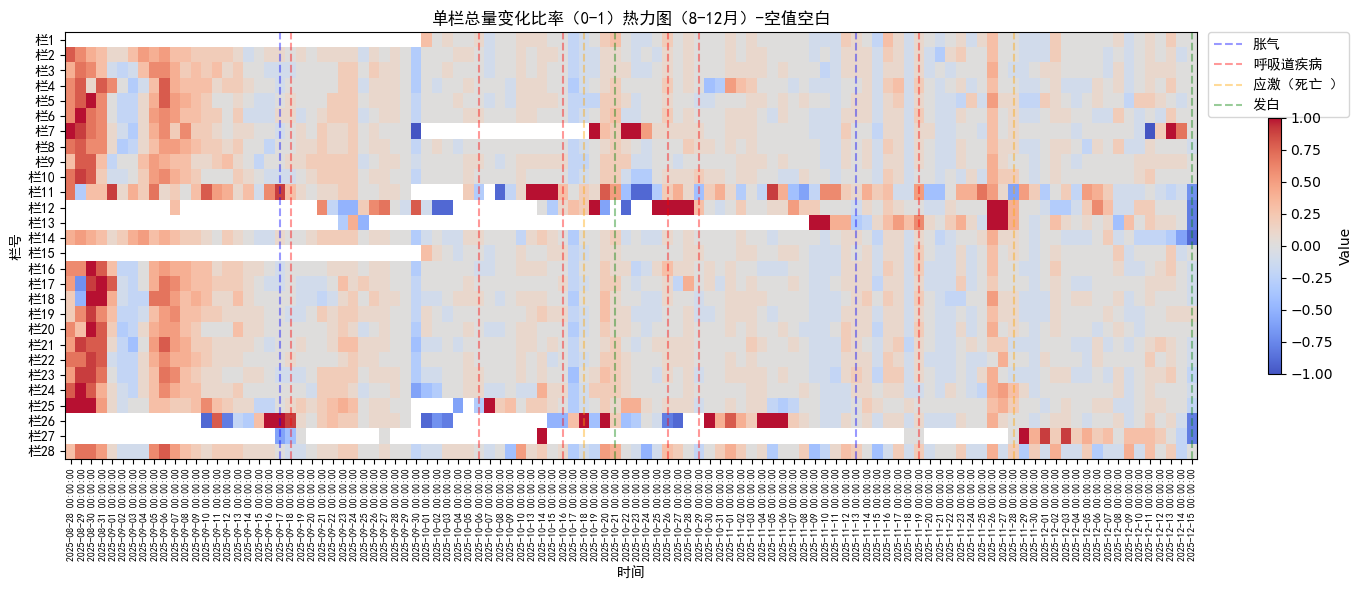

In [16]:
import matplotlib.dates as mdates

data = df_num.values

plt.figure(figsize=(15, 6))
im = plt.imshow(
    data,
    aspect='auto',      # 让时间轴拉伸
    cmap='coolwarm',
    origin='upper',      # 时间从上往下
    vmin = -1,
    vmax = 1,
    alpha=0.95,
)

plt.colorbar(im, label='Value', shrink=0.6)
plt.xlabel('时间', fontproperties = CN_font)
plt.ylabel('栏号', fontproperties = CN_font)

# 如果想显示真实刻度

plt.xticks(
    ticks=np.arange(len(df_num.columns)),
    labels=df_num.columns,
    rotation=90, fontproperties=CN_font, fontsize=7)

plt.yticks(
    ticks=np.arange(len(df_num.index)),
    labels=df_num.index,
    fontproperties=CN_font,
)

# 绘制垂直虚线
used_label = set()
for date in err_dates:
    if date in df_num.columns:
        x_pos = np.where(df_num.columns == date)[0][0]
        event_type = err_df.loc[err_df['Date'] == date, 'err_type'].iloc[0]
        color = color_map_event[event_type]
        event_label = type_map_event[event_type] if type_map_event[event_type] not in used_label else None
        used_label.add(event_label)
        plt.axvline(x=x_pos, linestyle='--', color=color, alpha=0.4, label=event_label)

plt.title('单栏总量变化比率（0-1）热力图（8-12月）-空值空白', fontproperties=CN_font, fontsize=12)
# legend 放在坐标轴外（右侧）
plt.legend(
    fontsize=7,
    loc='upper left',             # 相对于 bbox_to_anchor 的位置
    bbox_to_anchor=(1.01, 1),    # (x, y) 超过 1 表示在坐标轴外
    borderaxespad=0,              # 调整与坐标轴间距
    prop=CN_font
)

plt.tight_layout()
plt.show()


#### 10-12月

In [17]:
start_date = '2025-10-01'
end_date = '2025-12-31'

df_selected = df_num.loc[:, (df_num.columns >= start_date) & (df_num.columns <= end_date)]
data = df_selected.values

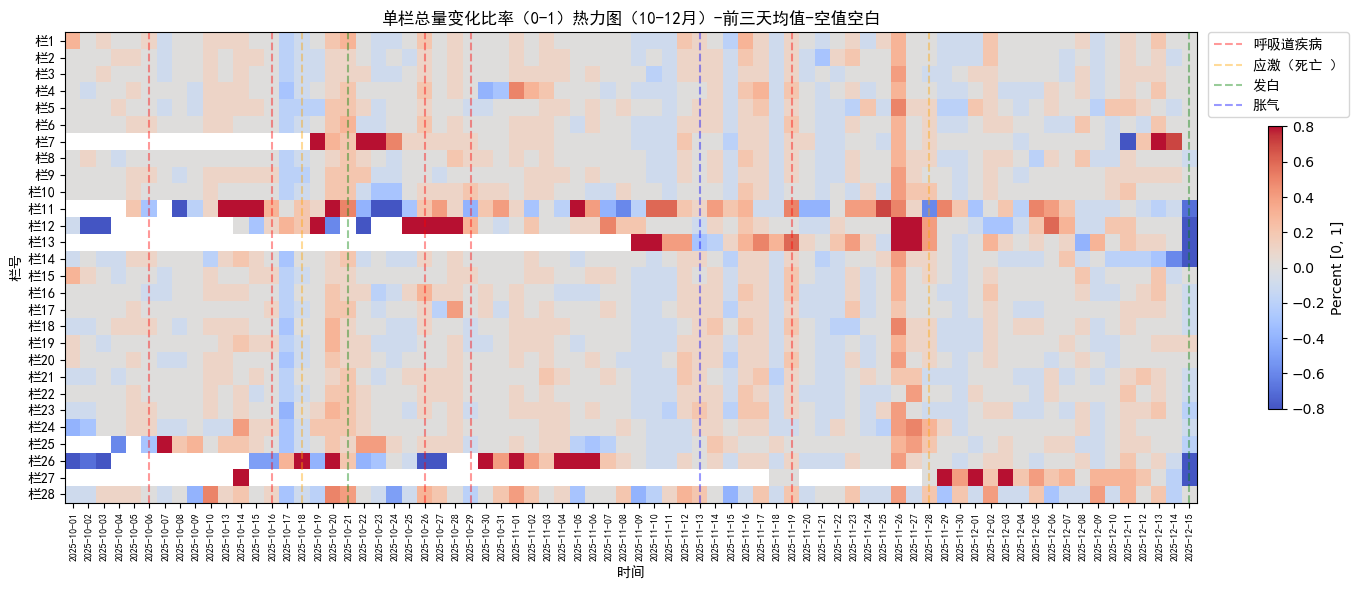

In [18]:
plt.figure(figsize=(15, 6))
im = plt.imshow(
    data,
    aspect='auto',
    cmap='coolwarm',
    origin='upper',
    vmin=-0.8,
    vmax=0.8,
    alpha=0.95,
)

plt.colorbar(im, label='Percent [0, 1]', shrink=0.6)
plt.xlabel('时间', fontproperties=CN_font)
plt.ylabel('栏号', fontproperties=CN_font)

plt.xticks(
    ticks=np.arange(len(df_selected.columns)),
    labels=df_selected.columns.strftime('%Y-%m-%d'),
    rotation=90,
    fontproperties=CN_font,
    fontsize=7
)
plt.yticks(
    ticks=np.arange(len(df_selected.index)),
    labels=df_selected.index,
    fontproperties=CN_font
)

# 绘制垂直虚线
used_label = set()
for date in err_dates:
    if date in df_selected.columns:
        x_pos = np.where(df_selected.columns == date)[0][0]
        event_type = err_df.loc[err_df['Date'] == date, 'err_type'].iloc[0]
        color = color_map_event[event_type]
        event_label = type_map_event[event_type] if type_map_event[event_type] not in used_label else None
        used_label.add(event_label)
        plt.axvline(x=x_pos, linestyle='--', color=color, alpha=0.4, label=event_label)

plt.title('单栏总量变化比率（0-1）热力图（10-12月）-前三天均值-空值空白', fontproperties=CN_font, fontsize=12)

# legend 放在坐标轴外（右侧）
plt.legend(
    fontsize=7,
    loc='upper left',             # 相对于 bbox_to_anchor 的位置
    bbox_to_anchor=(1.01, 1),    # (x, y) 超过 1 表示在坐标轴外
    borderaxespad=0,              # 调整与坐标轴间距
    prop=CN_font
)

plt.tight_layout()
plt.show()


## 4 预测头数变化量可视化

In [19]:
import pandas as pd

df_ori  = pd.read_excel('data/育肥4-2单元饲喂记录-2025-08-26--2025-12-16-单栏分析.xlsx', index_col=0)    # 单栏总量-当量头数分析
food_df = pd.read_excel('data/std_food_table.xlsx', index_col=False)

In [20]:
df_predN = pd.DataFrame({'Age': df_ori['Age']})
for col_number in range(1, 29):
    exp_df = df_ori[['Age', col_number]].copy()
    df_predN[f'col{col_number}'] = exp_df[col_number].to_numpy() / food_df['food_e'].to_numpy()

df_predN_copy = df_predN.copy()     # 备份计算值

In [21]:
df_predN.head()

,Age,col1,col2,col3,col4,col5,col6,col7,col8,col9,...,col19,col20,col21,col22,col23,col24,col25,col26,col27,col28
日期,,,,,,,,,,,,,,,,,,,,,
2025-08-26,26,11.420123,102.781108,137.041478,102.781108,91.360985,102.781108,114.201232,102.781108,102.781108,...,148.461601,102.781108,114.201232,137.041478,114.201232,102.781108,34.260369,34.260369,11.420123,125.621355
2025-08-27,27,0.000000,49.774071,70.513267,58.069749,62.217588,58.069749,58.069749,58.069749,45.626231,...,62.217588,62.217588,62.217588,62.217588,62.217588,70.513267,12.443518,4.147839,0.000000,62.217588
2025-08-28,28,0.000000,43.474090,51.145988,46.031389,43.474090,43.474090,53.703287,46.031389,33.244892,...,43.474090,48.588688,43.474090,48.588688,46.031389,56.260587,17.901096,0.000000,0.000000,40.916790
2025-08-29,29,0.000000,37.211589,50.235645,46.514486,44.653907,48.375066,53.956804,46.514486,37.211589,...,44.653907,35.351010,48.375066,48.375066,50.235645,59.538543,20.466374,0.000000,0.000000,44.653907
2025-08-30,30,0.000000,33.801877,49.967992,29.392936,57.316226,47.028698,52.907285,45.559051,39.680464,...,51.437638,55.846579,51.437638,55.846579,55.846579,63.194813,20.575055,0.000000,0.000000,47.028698


#### 差分方法

##### （1）8-12月

In [22]:
# 对每一列计算一阶差分，忽略缺失值，可加 fillna
df_diff = df_predN.iloc[1:, 1:].pct_change(axis=0).fillna(0)  # 第一行会变为 NaN，填 0
df_diff = df_diff.T


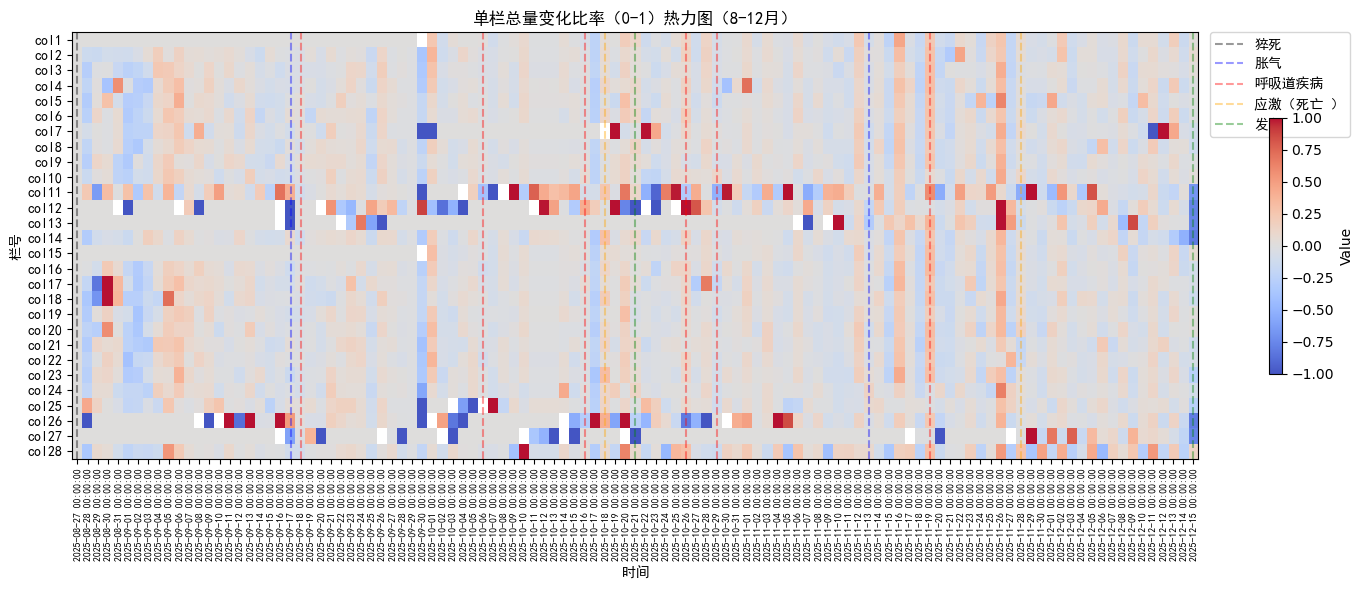

In [23]:
data = df_diff.values

plt.figure(figsize=(15, 6))
im = plt.imshow(
    data,
    aspect='auto',      # 让时间轴拉伸
    cmap='coolwarm',
    origin='upper',      # 时间从上往下
    vmin = -1,
    vmax = 1,
    alpha=0.95,
)

plt.colorbar(im, label='Value', shrink=0.6)
plt.xlabel('时间', fontproperties = CN_font)
plt.ylabel('栏号', fontproperties = CN_font)

# 如果想显示真实刻度

plt.xticks(
    ticks=np.arange(len(df_diff.columns)),
    labels=df_diff.columns,
    rotation=90, fontproperties=CN_font, fontsize=7)

plt.yticks(
    ticks=np.arange(len(df_diff.index)),
    labels=df_diff.index,
    fontproperties=CN_font,
)

# 绘制垂直虚线
used_label = set()
for date in err_dates:
    if date in df_diff.columns:
        x_pos = np.where(df_diff.columns == date)[0][0]
        event_type = err_df.loc[err_df['Date'] == date, 'err_type'].iloc[0]
        color = color_map_event[event_type]
        event_label = type_map_event[event_type] if type_map_event[event_type] not in used_label else None
        used_label.add(event_label)
        plt.axvline(x=x_pos, linestyle='--', color=color, alpha=0.4, label=event_label)

plt.title('单栏总量变化比率（0-1）热力图（8-12月）', fontproperties=CN_font, fontsize=12)
# legend 放在坐标轴外（右侧）
plt.legend(
    fontsize=7,
    loc='upper left',             # 相对于 bbox_to_anchor 的位置
    bbox_to_anchor=(1.01, 1),    # (x, y) 超过 1 表示在坐标轴外
    borderaxespad=0,              # 调整与坐标轴间距
    prop=CN_font
)

plt.tight_layout()
plt.show()


##### （2）10-12月

In [24]:
start_date = '2025-10-01'
end_date = '2025-12-31'

# 对每一列计算一阶差分，忽略缺失值，可加 fillna
df_diff = df_predN.iloc[1:, 1:].pct_change(axis=0).fillna(0)  # 第一行会变为 NaN，填 0
df_diff = df_diff.T

df_selected = df_diff.loc[:, (df_diff.columns >= start_date) & (df_diff.columns <= end_date)]


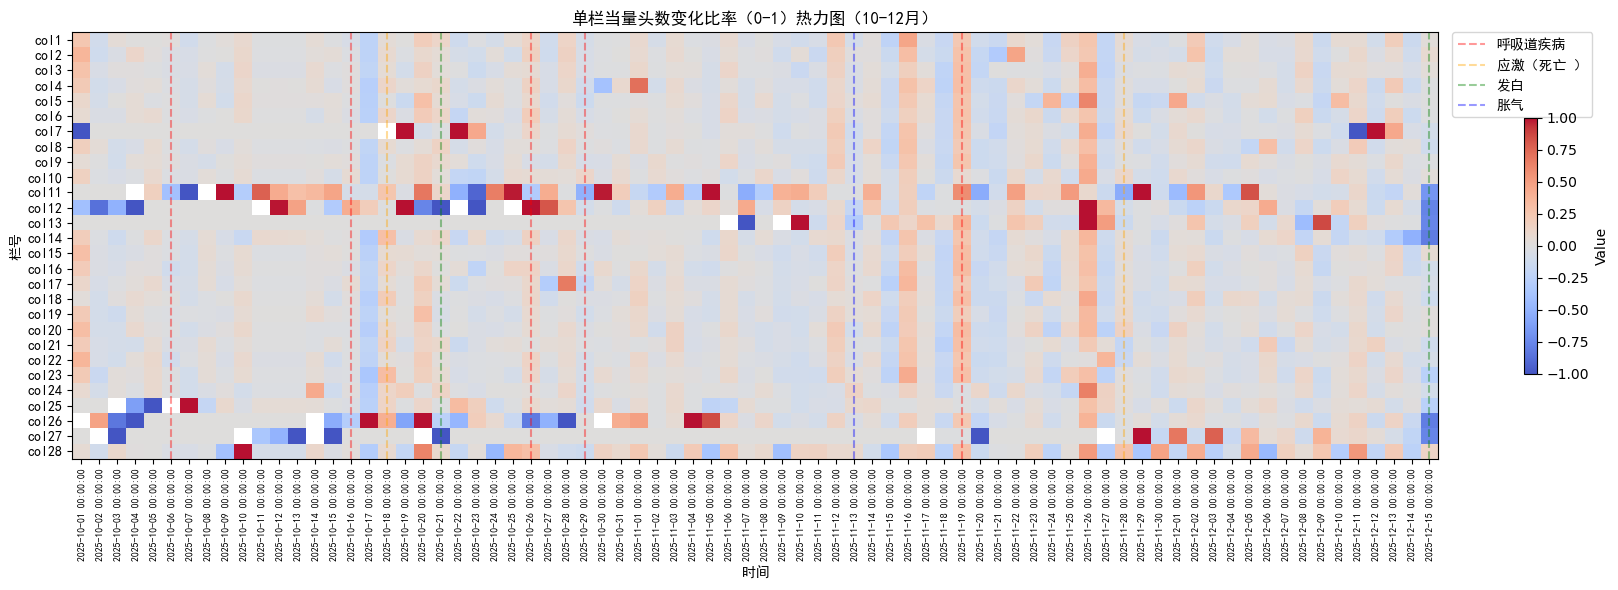

In [25]:
data = df_selected.values

plt.figure(figsize=(18, 6))
im = plt.imshow(
    data,
    aspect='auto',      # 让时间轴拉伸
    cmap='coolwarm',
    origin='upper',      # 时间从上往下
    vmin = -1,
    vmax = 1,
    alpha=0.95,
)

plt.colorbar(im, label='Value', shrink = 0.6)
plt.xlabel('时间', fontproperties = CN_font)
plt.ylabel('栏号', fontproperties = CN_font)

# 如果想显示真实刻度

plt.xticks(
    ticks=np.arange(len(df_selected.columns)),
    labels=df_selected.columns,
    rotation=90, fontproperties=CN_font, fontsize=7)

plt.yticks(
    ticks=np.arange(len(df_selected.index)),
    labels=df_selected.index,
    fontproperties=CN_font,
)

# 绘制垂直虚线
used_label = set()
for date in err_dates:
    if date in df_selected.columns:
        x_pos = np.where(df_selected.columns == date)[0][0]
        event_type = err_df.loc[err_df['Date'] == date, 'err_type'].iloc[0]
        color = color_map_event[event_type]
        event_label = type_map_event[event_type] if type_map_event[event_type] not in used_label else None
        used_label.add(event_label)
        plt.axvline(x=x_pos, linestyle='--', color=color, alpha=0.4, label=event_label)

plt.title('单栏当量头数变化比率（0-1）热力图（10-12月）', fontproperties=CN_font, fontsize=12)
# legend 放在坐标轴外（右侧）
plt.legend(
    fontsize=7,
    loc='upper left',             # 相对于 bbox_to_anchor 的位置
    bbox_to_anchor=(1.01, 1),    # (x, y) 超过 1 表示在坐标轴外
    borderaxespad=0,              # 调整与坐标轴间距
    prop=CN_font
)

plt.tight_layout()
plt.show()


#### SVD + MAD 方法

方法参考来自：gpt

In [27]:
# start_date = '2025-10-01'
# end_date = '2025-12-31'

# df = df_predN.drop(columns=['Age'])

# import numpy as np
# import pandas as pd
# from sklearn.decomposition import TruncatedSVD
# from statsmodels.robust.scale import mad
# import matplotlib.pyplot as plt
# import seaborn as sns

# # X: T x 28 numpy matrix (values)
# X = df.values.astype(float)
# time_index = df.index
# mask = (time_index >= start_date) & (time_index <= end_date)

# cols = df.columns

# # 标准化（按列）
# means = np.nanmean(X, axis=0)
# stds  = np.nanstd(X, axis=0)
# Xz = (X - means) / (stds + 1e-8)

# # 1) SVD 低秩重构 (选 k)
# k = 3  # 可以用 explained variance 来选择
# svd = TruncatedSVD(n_components=k, random_state=0)
# U = svd.fit_transform(Xz)      # T x k
# Vt = svd.components_           # k x 28
# L = U.dot(Vt)                  # 低秩近似，T x 28

# # 2) 残差
# R = Xz - L

# # 3) 用 MAD 设阈值（全局或按列）
# # 按元素的绝对残差计算 MAD（对所有元素）
# mad_all = mad(R.flatten(), center=0)
# threshold = 4 * mad_all

# anomaly_mask = np.abs(R) > threshold

# # 输出异常列表
# anomalies = []
# T, N = R.shape
# for t in range(T):
#     for i in range(N):
#         if anomaly_mask[t, i]:
#             anomalies.append({
#                 "time": time_index[t],
#                 "series": cols[i],
#                 "residual": R[t, i]
#             })
# anomalies_df = pd.DataFrame(anomalies).sort_values(['time','series'])

# # 4) 可视化热力图（残差绝对值）
# plt.figure(figsize=(15,6))
# # sns.heatmap(np.abs(R), cmap='viridis', cbar_kws={'label':'|residual (std units)|'}, xticklabels=cols, yticklabels=False)
# sns.heatmap(np.abs(R[mask, :]).T, cmap='viridis', 
#             cbar_kws={'label':'|residual (std units)|'}, 
#             xticklabels=time_index[mask], 
#             yticklabels=cols)
# plt.title('Residual heatmap (|X - lowrank|) Oct.-Dec.')
# plt.show()


## 5 基于平滑的总量变化量可视化

以平滑窗口对整体数据进行平滑，计算T天相较于T-3天的饮食变化率

#### 8-12月

In [ ]:
# 配置数据
# Config Param
SMOOTH_WIN = 2  # 平滑窗口
LAG = 2         # 滞后阶数

# Config Plot
from matplotlib import font_manager
CN_font = font_manager.FontProperties(fname='C:/Windows/Fonts/simhei.ttf')

color_map_event = {
    1: 'green',
    2: 'red',
    3: 'orange',
    4: 'blue',
    9: 'black',
    -1: 'yellow',
}

type_map_event = {
    1: '发白',
    2: '呼吸道疾病',
    3: '应激（死亡）',
    4: '胀气',
    # 5: 'purple',
    9: '猝死',

    -1: '治疗'
}

In [ ]:
import pandas as pd
import numpy as np

# Food data
df = pd.read_excel('data/育肥4-2单元饲喂记录-2025-08-26--2025-12-16-单栏分析.xlsx', sheet_name='子表1-单栏喂料量', index_col=False).rename(columns={'日期': 'Date'}).drop(columns=['Age'])

# Event Data
err_df = pd.read_excel('data/4栋2单元零星死亡数据.xlsx', index_col=False)

err_df = err_df[::-1].reset_index(drop=True)   # reverse date
err_df['Date'] = pd.to_datetime(err_df['Date'] )

err_mask = err_df['die_case'] >= 1
err_dates = pd.to_datetime(err_df.loc[err_mask, 'Date'])

计算平滑-变化率结果

In [ ]:
# 构造平滑序列
df_for_smooth = df.drop(columns=['Date']).replace(0, np.nan)   # 保证NaN不参与平滑计算，临时表格

df_smooth = (
    df_for_smooth.rolling(window=SMOOTH_WIN, center=True, min_periods=1).mean()
)
df_smooth[df == 0] = 0  # 回填0

# 构造滞后序列
df_smooth_lag = df_smooth.shift(LAG)

# 计算滞后变化率
df_pct_change = (df_smooth - df_smooth_lag) / df_smooth_lag * 100 # 转为百分比
df_pct_change.index = df['Date']    # 添加日期
df_pct_change = df_pct_change[3:]   # 剔除空行


In [ ]:
# df_pct_change

In [ ]:
# 转标准数字，保证顺利绘图
df_num = df_pct_change.apply(pd.to_numeric, errors='coerce')
df_num = df_num.fillna(float('inf'))
df_num.index = df_pct_change.index

df_num = df_num.T

In [ ]:
# df_num

In [ ]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

data = df_num.values

plt.figure(figsize=(15, 6))
im = plt.imshow(
    data,
    aspect='auto',      # 让时间轴拉伸
    cmap='coolwarm',
    origin='upper',      # 时间从上往下
    vmin = -80,
    vmax = 80,
    alpha=0.95,
)

plt.colorbar(im, label='Value', shrink=0.6)
plt.xlabel('时间', fontproperties = CN_font)
plt.ylabel('栏号', fontproperties = CN_font)

# 如果想显示真实刻度

plt.xticks(
    ticks=np.arange(len(df_num.columns)),
    labels=df_num.columns,
    rotation=90, fontproperties=CN_font, fontsize=7)

plt.yticks(
    ticks=np.arange(len(df_num.index)),
    labels=df_num.index,
    fontproperties=CN_font,
)

# 绘制垂直虚线
used_label = set()
for date in err_dates:
    if date in df_num.columns:
        x_pos = np.where(df_num.columns == date)[0][0]
        event_type = err_df.loc[err_df['Date'] == date, 'err_type'].iloc[0]
        color = color_map_event[event_type]
        event_label = type_map_event[event_type] if type_map_event[event_type] not in used_label else None
        used_label.add(event_label)
        plt.axvline(x=x_pos, linestyle='--', color=color, alpha=0.4, label=event_label)

plt.title('单栏总量变化比率（0-1）热力图（8-12月）-空值空白', fontproperties=CN_font, fontsize=12)
# legend 放在坐标轴外（右侧）
plt.legend(
    fontsize=7,
    loc='upper left',             # 相对于 bbox_to_anchor 的位置
    bbox_to_anchor=(1.01, 1),    # (x, y) 超过 1 表示在坐标轴外
    borderaxespad=0,              # 调整与坐标轴间距
    prop=CN_font
)

# 图细节
    
ax = plt.gca()
# ax.yaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=90, fontproperties=CN_font, fontsize=7)

plt.title('单栏总量-8-12月-T与T-3-空值空白（window=4）')
plt.legend(prop = CN_font, loc='upper right')
plt.show()


#### 10-12月

In [ ]:
start_date = '2025-10-01'
end_date = '2025-12-31'

df_selected = df_num.loc[:, (df_num.columns >= start_date) & (df_num.columns <= end_date)]
data = df_selected.values

In [ ]:
plt.figure(figsize=(15, 6))
im = plt.imshow(
    data,
    aspect='auto',
    cmap='coolwarm',
    origin='upper',
    vmin=-80,
    vmax=80,
    alpha=0.95,
)

plt.colorbar(im, label='Percent [-100, 100]', shrink=0.6)
plt.xlabel('时间', fontproperties=CN_font)
plt.ylabel('栏号', fontproperties=CN_font)

plt.xticks(
    ticks=np.arange(len(df_selected.columns)),
    labels=df_selected.columns.strftime('%Y-%m-%d'),
    rotation=90,
    fontproperties=CN_font,
    fontsize=7
)
plt.yticks(
    ticks=np.arange(len(df_selected.index)),
    labels=df_selected.index,
    fontproperties=CN_font
)

# 绘制垂直虚线
used_label = set()
for date in err_dates:
    if date in df_selected.columns:
        x_pos = np.where(df_selected.columns == date)[0][0]
        event_type = err_df.loc[err_df['Date'] == date, 'err_type'].iloc[0]
        color = color_map_event[event_type]
        event_label = type_map_event[event_type] if type_map_event[event_type] not in used_label else None
        used_label.add(event_label)
        plt.axvline(x=x_pos, linestyle='--', color=color, alpha=0.4, label=event_label)

plt.title('单栏总量-8-12月-T与T-3-空值空白（window=4）', fontproperties=CN_font, fontsize=12)

# legend 放在坐标轴外（右侧）
plt.legend(
    fontsize=7,
    loc='upper left',             # 相对于 bbox_to_anchor 的位置
    bbox_to_anchor=(1.01, 1),    # (x, y) 超过 1 表示在坐标轴外
    borderaxespad=0,              # 调整与坐标轴间距
    prop=CN_font
)

plt.tight_layout()
plt.show()


## 6 所有单元 单栏-基于平滑的总量变化率可视化

#### 1）总量变化量

In [61]:
# 配置数据
# 数据处理配置

# 数据文件配置
file_name = '育肥3-1单元饲喂记录-2025-08-28--2025-12-10'
# sheet_name = '子表1-单栏喂料量'

if_partial = False   # 是否只处理部分数据
start_date = '2025-10-01'
end_date = '2025-12-31'

# 绘图参数配置
from matplotlib import font_manager
CN_font = font_manager.FontProperties(fname='C:/Windows/Fonts/simhei.ttf')


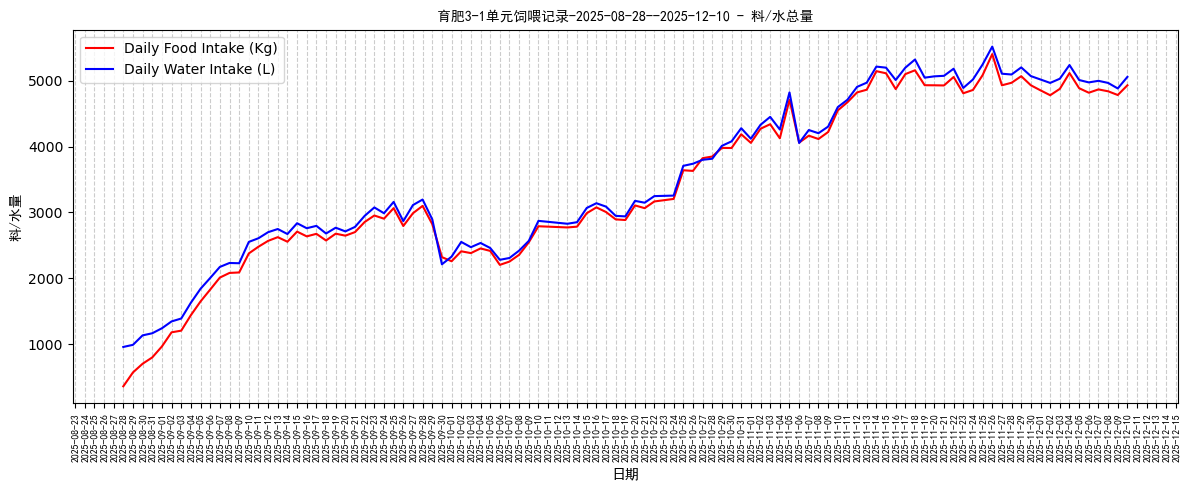

In [62]:
# 数据读取
import pandas as pd
df = pd.read_excel(f'data/{file_name}.xlsx', index_col=0, header=3).loc[::-1, ['转舍前日龄', '每日采食总量(Kg)', '每日喂水总量(L)']].drop_duplicates()
df.index = pd.to_datetime(df.index)

# 绘图
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['每日采食总量(Kg)'] * 3, label='Daily Food Intake (Kg)', color='red')
plt.plot(df.index, df['每日喂水总量(L)'], label='Daily Water Intake (L)', color='blue')
plt.xlabel('日期', fontproperties=CN_font)
plt.ylabel('料/水量', fontproperties=CN_font)
plt.title(f'{file_name} - 料/水总量', fontproperties=CN_font)

# 图细节
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.grid(axis='x', linestyle='--', color='gray', alpha=0.4)  # 只显示 x 轴网格线

plt.xticks(rotation=90, fontproperties=CN_font, fontsize=7)
plt.legend()
plt.tight_layout()
plt.savefig(f'figure/{file_name}-料水总量.png', dpi=300, bbox_inches='tight')
plt.show()

#### 2）总量变化率 & 添加治疗数据

In [ ]:
# 配置数据
# 数据处理配置
SMOOTH_WIN = 2  # 平滑窗口大小
LAG = 2         # 滞后阶数

# 数据文件配置
file_name = '育肥3-4单元饲喂记录-2025-08-28--2025-12-10-子表分析'
sheet_name = '子表1-单栏喂料量'

if_partial = False   # 是否只处理部分数据
start_date = '2025-10-01'
end_date = '2025-12-31'

# 绘图参数配置
from matplotlib import font_manager
CN_font = font_manager.FontProperties(fname='C:/Windows/Fonts/simhei.ttf')


1. 处理食料数据

In [ ]:
# 数据读取与平滑
import pandas as pd
import numpy as np

# Food data
df = pd.read_excel(f'data/{file_name}.xlsx', sheet_name=sheet_name, index_col=False).rename(columns={'日期': 'Date'}).drop(columns=['Age'], errors='ignore')
# df['Date'] = pd.to_datetime(df['Date'])

# 如果只处理部分数据
if if_partial:
    df = df[(df['Date'] >= start_date) & (df['Date'] <= end_date)].reset_index(drop=True)

# 构造平滑序列
df_for_smooth = df.drop(columns=['Date']).replace(0, np.nan)   # 保证NaN不参与平滑计算，临时表格

df_smooth = (
    df_for_smooth.rolling(window=SMOOTH_WIN, center=True, min_periods=1).mean()
)
df_smooth[df == 0] = 0  # 回填0

# 构造滞后序列
df_smooth_lag = df_smooth.shift(LAG)

# 计算滞后变化率
df_pct_change = (df_smooth - df_smooth_lag) / df_smooth_lag * 100 # 转为百分比
df_pct_change.index = df['Date']    # 添加日期
df_pct_change = df_pct_change[LAG:]   # 剔除空行

# 转标准数字，保证顺利绘图
df_num = df_pct_change.apply(pd.to_numeric, errors='coerce')
df_num = df_num.fillna(float('inf'))
df_num.index = df_pct_change.index

df_num = df_num.T

2. 处理event数据

In [ ]:
# 配置数据
# 数据文件配置
read_file_name = '治疗数据'
sheet_name = '03栋商品猪舍1单元'

# 绘图参数配置
color_map_event = {
    '发热': 'red',
    '神经症状': 'green',
    '咳嗽': 'blue',
}

In [ ]:
# 添加治疗数据
import pandas as pd

df = pd.read_excel(f'data/event/{read_file_name}.xlsx', sheet_name=sheet_name, index_col=False)[['治疗日期', '数量', '疾病名称']]
# 只保留日期部分
df['治疗日期'] = pd.to_datetime(df['治疗日期']).dt.date 

# 合并同一天的事件
df = df.groupby(['治疗日期', '疾病名称'], as_index=False)['数量'].sum()
df_event = df       # 用于绘制事件线

event_dates = df_event['治疗日期']

3. 绘图

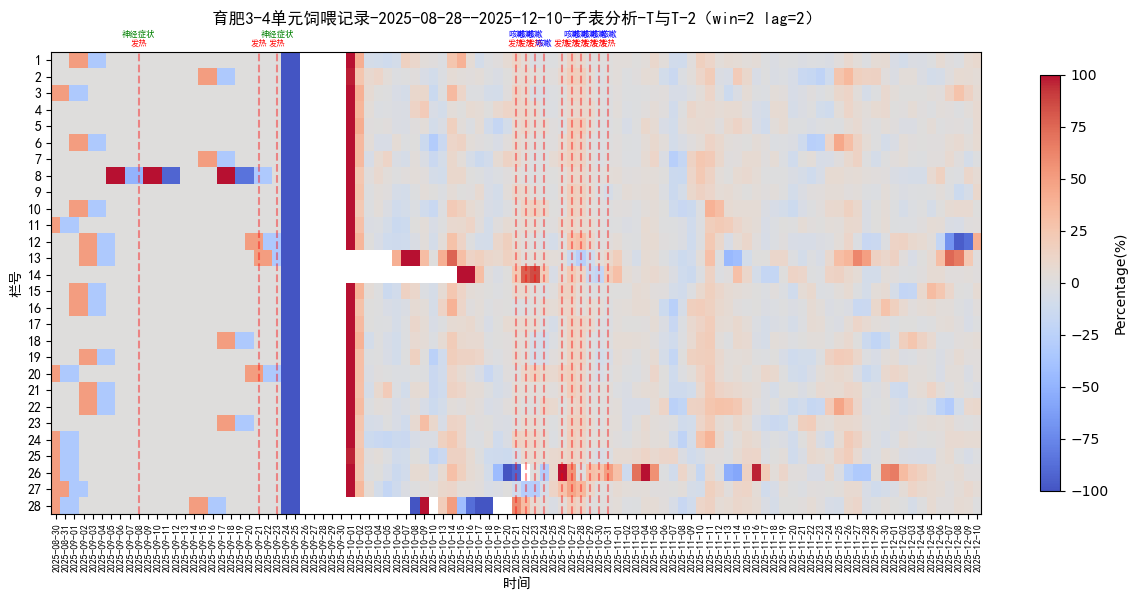

In [ ]:
# 绘图
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

data = df_num.values

# 1）绘制整体曲线
plt.figure(figsize=(15, 6))
im = plt.imshow(
    data,
    aspect='auto',      # 让时间轴拉伸
    cmap='coolwarm',
    origin='upper',      # 时间从上往下
    vmin = -100,
    vmax = 100,
    alpha=0.95,
)

plt.colorbar(im, label='Percentage(%)', shrink=0.9)
plt.xlabel('时间', fontproperties = CN_font)
plt.ylabel('栏号', fontproperties = CN_font)

# 2）绘制事件垂直虚线
ax = plt.gca()
used_label = set()

for date, group in df_event.groupby('治疗日期'):

    x_pos = df_num.columns.get_loc(pd.Timestamp(date))

    # 一天一条虚线
    ax.axvline(
        x=x_pos,
        linestyle='--',
        color='red',
        alpha=0.4,
        zorder=2
    )

    # 同一天多个 label
    for i, illness_type in enumerate(group['疾病名称']):
        color = color_map_event.get(illness_type, 'black')

        label = illness_type if illness_type not in used_label else None
        used_label.add(illness_type)

        ax.text(
            x_pos,
            1.01 + i * 0.02,   # 竖向错开
            illness_type,
            ha='center',
            va='bottom',
            transform=ax.get_xaxis_transform(),
            fontsize=6,
            color=color,
            fontproperties=CN_font
        )

# 3）图显示调整
# 显示真实刻度
plt.xticks(
    ticks=np.arange(len(df_num.columns)),
    labels=df_num.columns,
    rotation=90, fontproperties=CN_font, fontsize=7)

plt.yticks(
    ticks=np.arange(len(df_num.index)),
    labels=df_num.index,
    fontproperties=CN_font,
)

dates = pd.to_datetime(df_num.columns)
step = 1  # 每 1 天显示一次
tick_pos = np.arange(0, len(dates), step)

plt.xticks(
    ticks=tick_pos,
    labels=dates[tick_pos].strftime('%Y-%m-%d'),
    rotation=90,
    fontproperties=CN_font,
    fontsize=7
)

plt.title(f'{file_name}-T与T-{LAG}（win={SMOOTH_WIN} lag={LAG}）', fontproperties=CN_font, fontsize=12, pad=20)
plt.savefig(f'figure/{file_name}-T与T-{LAG}（win={SMOOTH_WIN} lag={LAG}）.png', dpi=300, bbox_inches='tight')
plt.show()

## 7 三栋栏数据总量变化

In [21]:
import pandas as pd
df_total = pd.read_excel('data/四单元统计.xlsx', index_col=0)
df_total.index = pd.to_datetime(df_total.index)

### 育肥3-1单元

In [22]:
# 配置数据
file_name = '育肥3-1单元饲喂记录-2025-08-28--2025-12-10-子表分析'
sheet_name = '子表1-单栏喂料量'

if_partial = False   # 是否只处理部分数据
start_date = '2025-10-01'
end_date = '2025-12-31'

# 绘图参数配置
from matplotlib import font_manager
CN_font = font_manager.FontProperties(fname='C:/Windows/Fonts/simhei.ttf')


In [23]:
import pandas as pd
df = pd.read_excel(f'data/{file_name}.xlsx', sheet_name=sheet_name, index_col=False).rename(columns={'日期': 'Date'}).drop(columns=['Age'], errors='ignore')
df['Date'] = pd.to_datetime(df['Date'])
df = df.merge(df_total['育肥3-1单元']/28, left_on='Date', right_on=df_total.index, how='left').rename(columns={'育肥3-1单元': 'Total'}) # 单栏总值平均值

In [24]:
if if_partial:
    df = df[(df['Date'] >= start_date) & (df['Date'] <= end_date)].reset_index(drop=True)

import pandas as pd
import plotly.express as px

# 为了 Plotly 交互，先把数据转成长格式
df_long = df.melt(id_vars='Date', var_name='Column', value_name='value')

fig = px.line(df_long, x='Date', y='value', color='Column', title=f'{file_name} 28列单栏喂料量变化曲线')
fig.update_layout(
    autosize=True,       # 自动调整画布大小
    height=500,          # 高度可以固定，也可以尝试设置为 None 自适应
    xaxis_title='日期',
    yaxis_title='料量/kg')

# 突出'Total'列，增加一列 alpha 或者 color
highlight_unit = 'Total'
df_long['opacity'] = df_long['Column'].apply(lambda x: 1.0 if x == highlight_unit else 0.6)
df_long['line_width'] = df_long['Column'].apply(lambda x: 4 if x == highlight_unit else 1)

# 设置线宽和透明度
for trace in fig.data:
    trace.opacity = 1.0 if trace.name == highlight_unit else 0.6
    trace.line.width = 4 if trace.name == highlight_unit else 1

# 设置 x 轴按天显示，日期标签旋转 90 度
fig.update_xaxes(
    dtick="D1",        # 每天一个刻度
    tickangle=-90,      # 标签旋转90度
    tickformat="%m-%d", # 可选：只显示月-日
    tickfont=dict(size=10)  # 调小字体，例如10号
)
fig.show()

### 育肥3-2单元

In [25]:
# 配置数据
file_name = '育肥3-2单元饲喂记录-2025-08-28--2025-12-10-子表分析'
sheet_name = '子表1-单栏喂料量'

if_partial = False   # 是否只处理部分数据
start_date = '2025-10-01'
end_date = '2025-12-31'

# 绘图参数配置
from matplotlib import font_manager
CN_font = font_manager.FontProperties(fname='C:/Windows/Fonts/simhei.ttf')


In [26]:
import pandas as pd
df = pd.read_excel(f'data/{file_name}.xlsx', sheet_name=sheet_name, index_col=False).rename(columns={'日期': 'Date'}).drop(columns=['Age'], errors='ignore')
df['Date'] = pd.to_datetime(df['Date'])
df = df.merge(df_total['育肥3-2单元']/28, left_on='Date', right_on=df_total.index, how='left').rename(columns={'育肥3-2单元': 'Total'}) # 单栏总值平均值

if if_partial:
    df = df[(df['Date'] >= start_date) & (df['Date'] <= end_date)].reset_index(drop=True)

import pandas as pd
import plotly.express as px

# 为了 Plotly 交互，先把数据转成长格式
df_long = df.melt(id_vars='Date', var_name='Column', value_name='value')

fig = px.line(df_long, x='Date', y='value', color='Column', title=f'{file_name} 28列单栏喂料量变化曲线')
fig.update_layout(
    autosize=True,       # 自动调整画布大小
    height=500,          # 高度可以固定，也可以尝试设置为 None 自适应
    xaxis_title='日期',
    yaxis_title='料量/kg')

# 突出'Total'列，增加一列 alpha 或者 color
highlight_unit = 'Total'
df_long['opacity'] = df_long['Column'].apply(lambda x: 1.0 if x == highlight_unit else 0.6)
df_long['line_width'] = df_long['Column'].apply(lambda x: 4 if x == highlight_unit else 1)

# 设置线宽和透明度
for trace in fig.data:
    trace.opacity = 1.0 if trace.name == highlight_unit else 0.6
    trace.line.width = 4 if trace.name == highlight_unit else 1
    
# 设置 x 轴按天显示，日期标签旋转 90 度
fig.update_xaxes(
    dtick="D1",        # 每天一个刻度
    tickangle=-90,      # 标签旋转90度
    tickformat="%m-%d", # 可选：只显示月-日
    tickfont=dict(size=10)  # 调小字体，例如10号
)
fig.show()

### 育肥3-3单元

In [34]:
# 配置数据
file_name = '育肥3-3单元饲喂记录-2025-08-28--2025-12-10-子表分析'
sheet_name = '子表1-单栏喂料量'

if_partial = False   # 是否只处理部分数据
start_date = '2025-10-01'
end_date = '2025-12-31'

# 绘图参数配置
from matplotlib import font_manager
CN_font = font_manager.FontProperties(fname='C:/Windows/Fonts/simhei.ttf')


In [35]:
import pandas as pd
df = pd.read_excel(f'data/{file_name}.xlsx', sheet_name=sheet_name, index_col=False).rename(columns={'日期': 'Date'}).drop(columns=['Age'], errors='ignore')
df['Date'] = pd.to_datetime(df['Date'])
df = df.merge(df_total['育肥3-3单元']/28, left_on='Date', right_on=df_total.index, how='left').rename(columns={'育肥3-3单元': 'Total'}) # 单栏总值平均值

if if_partial:
    df = df[(df['Date'] >= start_date) & (df['Date'] <= end_date)].reset_index(drop=True)

import pandas as pd
import plotly.express as px

# 为了 Plotly 交互，先把数据转成长格式
df_long = df.melt(id_vars='Date', var_name='Column', value_name='value')

fig = px.line(df_long, x='Date', y='value', color='Column', title=f'{file_name} 28列单栏喂料量变化曲线')
fig.update_layout(
    autosize=True,       # 自动调整画布大小
    height=500,          # 高度可以固定，也可以尝试设置为 None 自适应
    xaxis_title='日期',
    yaxis_title='料量/kg')

# 突出'Total'列，增加一列 alpha 或者 color
highlight_unit = 'Total'
df_long['opacity'] = df_long['Column'].apply(lambda x: 1.0 if x == highlight_unit else 0.6)
df_long['line_width'] = df_long['Column'].apply(lambda x: 4 if x == highlight_unit else 1)

# 设置线宽和透明度
for trace in fig.data:
    trace.opacity = 1.0 if trace.name == highlight_unit else 0.6
    trace.line.width = 4 if trace.name == highlight_unit else 1

# 设置 x 轴按天显示，日期标签旋转 90 度
fig.update_xaxes(
    dtick="D1",        # 每天一个刻度
    tickangle=-90,      # 标签旋转90度
    tickformat="%m-%d", # 可选：只显示月-日
    tickfont=dict(size=10)  # 调小字体，例如10号
)
fig.show()

### 育肥3-4单元

In [40]:
# 配置数据
file_name = '育肥3-4单元饲喂记录-2025-08-28--2025-12-10-子表分析'
sheet_name = '子表1-单栏喂料量'

if_partial = False   # 是否只处理部分数据
start_date = '2025-10-01'
end_date = '2025-12-31'

# 绘图参数配置
from matplotlib import font_manager
CN_font = font_manager.FontProperties(fname='C:/Windows/Fonts/simhei.ttf')


In [41]:
import pandas as pd
df = pd.read_excel(f'data/{file_name}.xlsx', sheet_name=sheet_name, index_col=False).rename(columns={'日期': 'Date'}).drop(columns=['Age'], errors='ignore')
df['Date'] = pd.to_datetime(df['Date'])
df = df.merge(df_total['育肥3-4单元']/28, left_on='Date', right_on=df_total.index, how='left').rename(columns={'育肥3-4单元': 'Total'}) # 单栏总值平均值

if if_partial:
    df = df[(df['Date'] >= start_date) & (df['Date'] <= end_date)].reset_index(drop=True)

import pandas as pd
import plotly.express as px

# 为了 Plotly 交互，先把数据转成长格式
df_long = df.melt(id_vars='Date', var_name='Column', value_name='value')

fig = px.line(df_long, x='Date', y='value', color='Column', title=f'{file_name} 28列单栏喂料量变化曲线')
fig.update_layout(
    autosize=True,       # 自动调整画布大小
    height=500,          # 高度可以固定，也可以尝试设置为 None 自适应
    xaxis_title='日期',
    yaxis_title='料量/kg')

# 突出'Total'列，增加一列 alpha 或者 color
highlight_unit = 'Total'
df_long['opacity'] = df_long['Column'].apply(lambda x: 1.0 if x == highlight_unit else 0.6)
df_long['line_width'] = df_long['Column'].apply(lambda x: 4 if x == highlight_unit else 1)

# 设置线宽和透明度
for trace in fig.data:
    trace.opacity = 1.0 if trace.name == highlight_unit else 0.6
    trace.line.width = 4 if trace.name == highlight_unit else 1

# 设置 x 轴按天显示，日期标签旋转 90 度
fig.update_xaxes(
    dtick="D1",        # 每天一个刻度
    tickangle=-90,      # 标签旋转90度
    tickformat="%m-%d", # 可选：只显示月-日
    tickfont=dict(size=10)  # 调小字体，例如10号
)
fig.show()

### 各单元比较

读取四个Excel，绘制不同单元的单元总量变化趋势，四条线对比

In [42]:
# 数据读取
import pandas as pd

file_name = ['育肥3-1单元饲喂记录-2025-08-28--2025-12-10', 
             '育肥3-2单元饲喂记录-2025-08-28--2025-12-10',
             '育肥3-3单元饲喂记录-2025-08-28--2025-12-10',
             '育肥3-4单元饲喂记录-2025-08-28--2025-12-10',
            ]

df = pd.read_excel(f'data/{file_name[0]}.xlsx', index_col=0, header=3).loc[::-1, ['每日采食总量(Kg)']].drop_duplicates()
for i in range(1, len(file_name)):
    df_temp = pd.read_excel(f'data/{file_name[i]}.xlsx', index_col=0, header=3).loc[::-1, ['每日采食总量(Kg)']].drop_duplicates()
    df[i] = df_temp['每日采食总量(Kg)']
df.columns = [ '育肥3-1单元', '育肥3-2单元', '育肥3-3单元', '育肥3-4单元' ]
df_long = df.reset_index().melt(id_vars='饲喂日期', var_name='Unit', value_name='Food Intake (Kg)')

df.to_excel('data/四单元统计.xlsx')

In [43]:
fig = px.line(df_long, x='饲喂日期', y='Food Intake (Kg)', color='Unit', title=f'3栋1-4单元食物总量变化趋势曲线')
fig.update_layout(
    autosize=True,       # 自动调整画布大小
    height=500,          # 高度可以固定，也可以尝试设置为 None 自适应
    xaxis_title='日期',
    yaxis_title='料量/kg')

# 设置 x 轴按天显示，日期标签旋转 90 度
fig.update_xaxes(
    dtick="D1",        # 每天一个刻度
    tickangle=-90,      # 标签旋转90度
    tickformat="%m-%d", # 可选：只显示月-日
    tickfont=dict(size=8)  # 调小字体，例如10号
)
fig.show()